In [2]:
import os
import sys
import pdb
import dask
import copy
import xrft
import cftime
import itertools
import importlib
import numpy as np
import scipy as sp
import xarray as xr
import wk_diags as wd
from glob import glob
import qbo_diags as qd
import kf_filter as kff
import kf_filter_dask as kfd
import plotting_scripts as ps
import matplotlib.colors as clr
import matplotlib.pyplot as plt
from dask.distributed import Client
from dask_jobqueue import PBSCluster
import matplotlib.patches as mpatches
from geocat.comp import interp_hybrid_to_pressure

# try peer-to-peer shuffling to see if it improves
# rechunking performance
dask.config.set({"array.rechunk.method": "p2p"})

In [33]:
importlib.reload(kfd)

<module 'kf_filter_dask' from '/glade/u/home/aaroj/python/aqua_qbo/kf_filter_dask.py'>

In [3]:
#### Initialize Constants #####

rearth = 6.37123e6 # radius of earth in m
omega = 7.29212e-5 # Earth's rotation rate in 1/s
p0 = 101325 # reference surface pressure in Pa
H = 7000 # scale height in m
g0 = 9.80665 # global average of gravity in m/s2
Rd = 287.058 # gas constant for dry air in J/kg*K
rho_surf = p0/(H*g0) # reference surface density in kg/m3
t_surf = g0*H/Rd # reference surface temperature in K
Cp = 1004.64 # specific heat at constant pressure for dry air, J/kg*K

# Filter Testing

<xarray.DataArray (component: 2, wavetype: 10, time: 100, lat: 61, lon: 360)> Size: 351MB
dask.array<xarray-<this-array>, shape=(2, 10, 100, 61, 360), dtype=float64, chunksize=(2, 10, 100, 1, 360), chunktype=numpy.ndarray>
Coordinates:
  * wavetype   (wavetype) <U10 400B 'KELVIN_box' 'MRG_box' ... 'no_filt'
  * time       (time) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * lat        (lat) int64 488B -30 -29 -28 -27 -26 -25 ... 25 26 27 28 29 30
  * lon        (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * component  (component) <U4 32B 'sym' 'asym'
data shape at beginning  Frozen({'component': 2, 'wavetype': 10, 'time': 100, 'lat': 61, 'lon': 360})
{'KELVIN_box': {'sym': {'freq_lon': [-20, 0], 'freq_time': [0, 0.4], 'hbnd': [None, None]}}, 'MRG_box': {'asym': {'freq_lon': [-20, 20], 'freq_time': [0.1, 0.5], 'hbnd': [None, None]}}, 'ER_box': {'sym': {'freq_lon': [0, 20], 'freq_time': [0, 0.4], 'hbnd': [None, None]}, 'asym': {'freq_lon': [-20, 20], '

ipdb>  z_filter


*** NameError: name 'z_filter' is not defined


ipdb>  z_fft_filter


<xarray.DataArray 'fftn-fd1ab533887b6fba3225f93b34fea5aa' (component: 2,
                                                           wavetype: 10,
                                                           freq_time: 100,
                                                           lat: 61,
                                                           freq_lon: 360)> Size: 703MB
dask.array<where, shape=(2, 10, 100, 61, 360), dtype=complex128, chunksize=(2, 10, 100, 1, 360), chunktype=numpy.ndarray>
Coordinates:
  * wavetype   (wavetype) <U10 400B 'KELVIN_box' 'MRG_box' ... 'no_filt'
  * lat        (lat) int64 488B -30 -29 -28 -27 -26 -25 ... 25 26 27 28 29 30
  * component  (component) <U4 32B 'sym' 'asym'
  * freq_time  (freq_time) float64 800B 0.0 0.04 0.08 0.12 ... -0.12 -0.08 -0.04
  * freq_lon   (freq_lon) float64 3kB 0.0 1.0 2.0 3.0 ... -4.0 -3.0 -2.0 -1.0


ipdb>  foo = z_fft_filter.compute()
ipdb>  foo = foo.real
ipdb>  import matplotlib.pyplot as plt
ipdb>  plt.imshow(foo.sel(wavetype = 'KELVIN_box',lat=20,component='sym'))


ipdb>  plt.show()


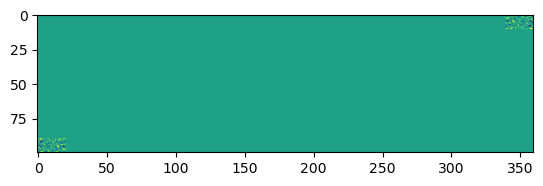

ipdb>  plt.imshow(foo.sel(wavetype = 'KELVIN_box',lat=20,component='asym'))


ipdb>  plt.show()


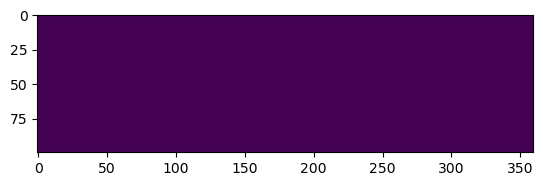

ipdb>  plt.imshow(foo.sel(wavetype = 'MRG_box',lat=20,component='sym'))


ipdb>  plt.show()


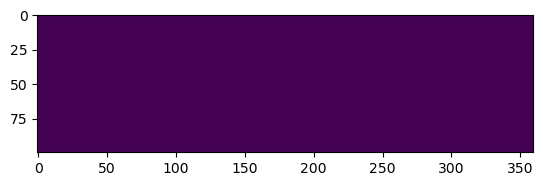

ipdb>  plt.imshow(foo.sel(wavetype = 'MRG_box',lat=20,component='asym'))


ipdb>  plt.show()


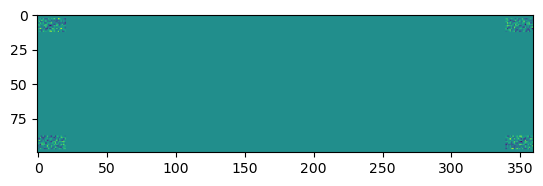

ipdb>  plt.imshow(foo.sel(wavetype = 'ER_box',lat=20,component='sym'))


ipdb>  plt.show()


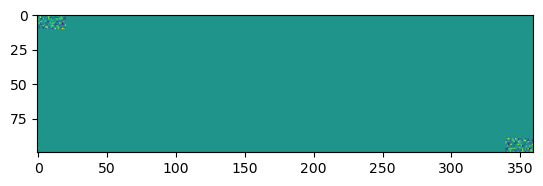

ipdb>  plt.imshow(foo.sel(wavetype = 'ER_box',lat=20,component='asym'))


ipdb>  plt.show()


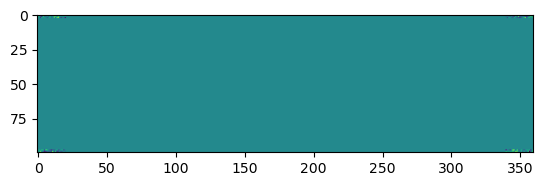

ipdb>  plt.imshow(foo.sel(wavetype = 'IG_box',lat=20,component='sym'))


ipdb>  plt.show()


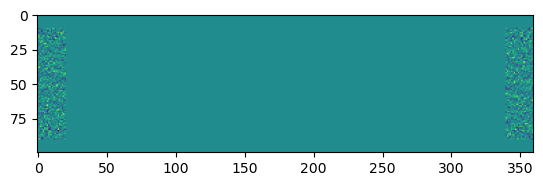

ipdb>  plt.imshow(foo.sel(wavetype = 'IG_box',lat=20,component='asym'))


ipdb>  plt.show()


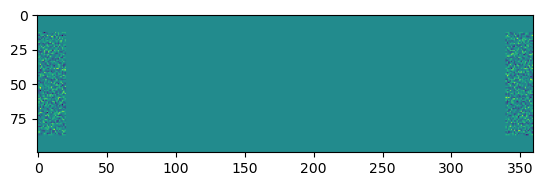

ipdb>  plt.imshow(foo.sel(wavetype = 'KELVIN_jjf',lat=20,component='sym'))


ipdb>  plt.show()


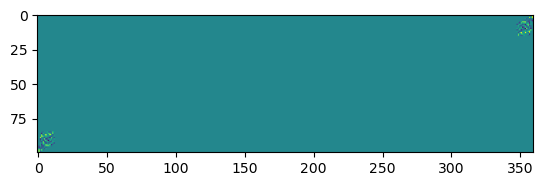

ipdb>  plt.imshow(foo.sel(wavetype = 'KELVIN_jjf',lat=20,component='asym'))


ipdb>  plt.show()


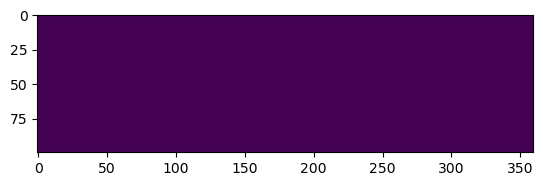

ipdb>  plt.imshow(foo.sel(wavetype = 'MRG_jjf',lat=20,component='sym'))


ipdb>  plt.show()


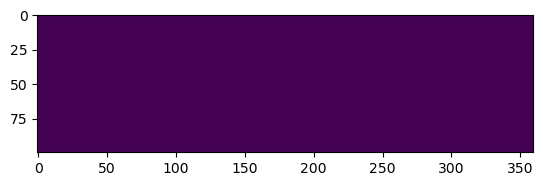

ipdb>  plt.imshow(foo.sel(wavetype = 'MRG_jjf',lat=20,component='asym'))


ipdb>  plt.show()


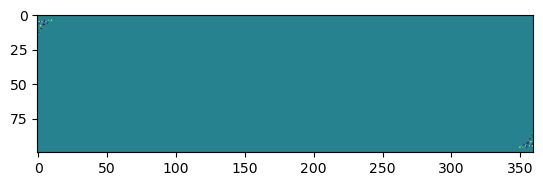

ipdb>  foo.freq_time


<xarray.DataArray 'freq_time' (freq_time: 100)> Size: 800B
array([ 0.  ,  0.04,  0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,
        0.4 ,  0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
        0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ,  1.04,  1.08,  1.12,  1.16,
        1.2 ,  1.24,  1.28,  1.32,  1.36,  1.4 ,  1.44,  1.48,  1.52,  1.56,
        1.6 ,  1.64,  1.68,  1.72,  1.76,  1.8 ,  1.84,  1.88,  1.92,  1.96,
       -2.  , -1.96, -1.92, -1.88, -1.84, -1.8 , -1.76, -1.72, -1.68, -1.64,
       -1.6 , -1.56, -1.52, -1.48, -1.44, -1.4 , -1.36, -1.32, -1.28, -1.24,
       -1.2 , -1.16, -1.12, -1.08, -1.04, -1.  , -0.96, -0.92, -0.88, -0.84,
       -0.8 , -0.76, -0.72, -0.68, -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44,
       -0.4 , -0.36, -0.32, -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04])
Coordinates:
  * freq_time  (freq_time) float64 800B 0.0 0.04 0.08 0.12 ... -0.12 -0.08 -0.04


ipdb>  plt.imshow(foo.sel(wavetype = 'ER_jjf',lat=20,component='sym'))


ipdb>  plt.show()


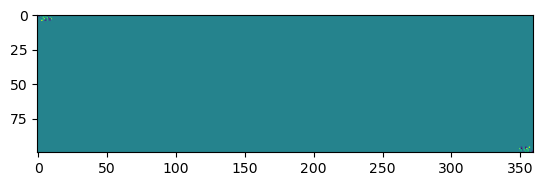

ipdb>  plt.imshow(foo.sel(wavetype = 'ER_jjf',lat=20,component='sym',freq_lon = slice(0,20),freq_time = slice(0,0.4)))


ipdb>  plt.show()


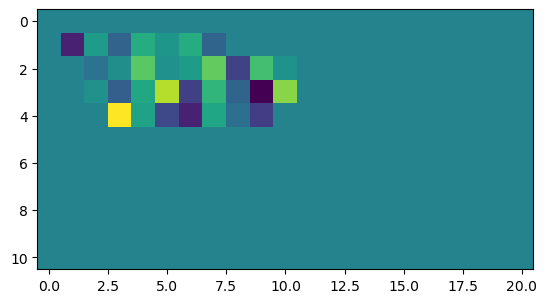

ipdb>  plt.imshow(foo.sel(wavetype = 'ER_jjf',lat=20,component='asym'))


ipdb>  plt.show()


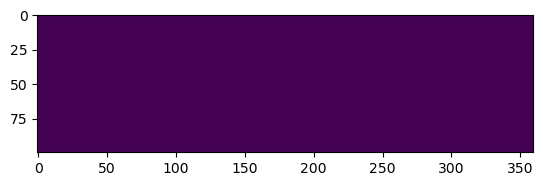

ipdb>  plt.imshow(foo.sel(wavetype = 'IG0_jjf',lat=20,component='sym'))


ipdb>  plt.show()


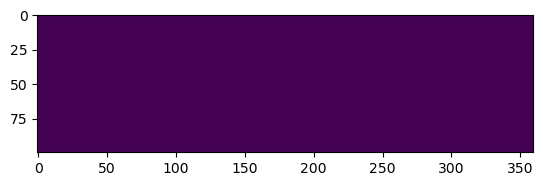

ipdb>  plt.imshow(foo.sel(wavetype = 'IG0_jjf',lat=20,component='asym'))


ipdb>  plt.show()


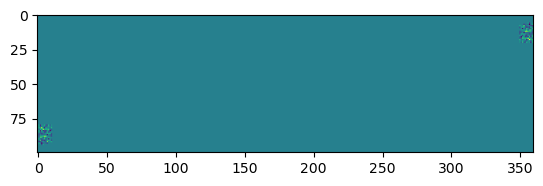

ipdb>  plt.imshow(foo.sel(wavetype = 'IG1_jjf',lat=20,component='sym'))


ipdb>  plt.show()


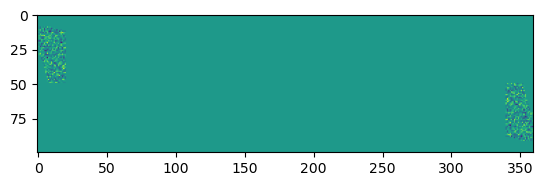

ipdb>  plt.imshow(foo.sel(wavetype = 'IG1_jjf',lat=20,component='asym'))


ipdb>  plt.show()


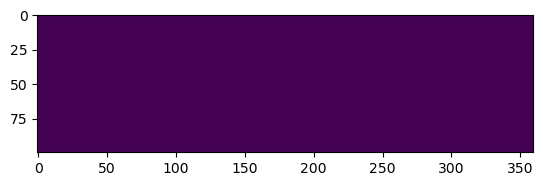

ipdb>  plt.imshow(foo.sel(wavetype = 'no_filt',lat=20,component='sym'))


ipdb>  plt.show()


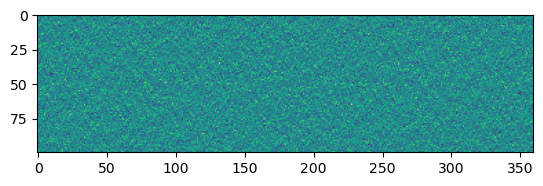

ipdb>  plt.imshow(foo.sel(wavetype = 'no_filt',lat=20,component='asym'))


ipdb>  plt.show()


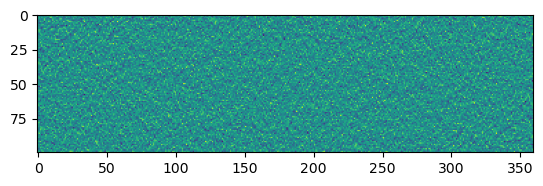

ipdb>  n


> /glade/u/home/aaroj/python/aqua_qbo/kf_filter_dask.py(636)kf_filter()
    634 
    635     z_filter = dsar.fft.ifftn(z_fft_filter,
--> 636                               axes = (lon_ax,time_ax)).real.astype('float32')
    637 
    638     z_filter = xr.DataArray(z_filter, dims = odims, 



ipdb>  


> /glade/u/home/aaroj/python/aqua_qbo/kf_filter_dask.py(635)kf_filter()
    633     #                      real_dim = 'freq_time')
    634 
--> 635     z_filter = dsar.fft.ifftn(z_fft_filter,
    636                               axes = (lon_ax,time_ax)).real.astype('float32')
    637 



ipdb>  


...

ipdb>  


The shape of the filtered space-time array is: (10, 100, 61, 360)
> /glade/u/home/aaroj/python/aqua_qbo/kf_filter_dask.py(651)kf_filter()
    648 
    649     print('The shape of the filtered space-time array is:', np.shape(z_filter))
    650 
--> 651     return z_filter
    652 



ipdb>  z_filter


<xarray.DataArray 'astype-48cb954adf6e4a52e68a6c9eff3c8e34' (wavetype: 10,
                                                             time: 100,
                                                             lat: 61, lon: 360)> Size: 88MB
dask.array<sum-aggregate, shape=(10, 100, 61, 360), dtype=float32, chunksize=(10, 100, 1, 360), chunktype=numpy.ndarray>
Coordinates:
  * wavetype  (wavetype) <U10 400B 'KELVIN_box' 'MRG_box' ... 'no_filt'
  * time      (time) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
  * lat       (lat) int64 488B -30 -29 -28 -27 -26 -25 -24 ... 25 26 27 28 29 30
  * lon       (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359


ipdb>  exit()


In [32]:
# filter_ranges = {'KELVIN_box':{'sym':{'freq_lon':[-20,0],
#                                       'freq_time':[0,0.4],
#                                       'hbnd':[None,None]}}}
foo = xr.DataArray(np.random.randn(len(wavetypes),100,61,360),
                   dims = ('wavetype','time','lat','lon'),
                   coords = {'wavetype':wavetypes,
                             'time':np.arange(100),
                             'lat':np.arange(-30,31,1),
                             'lon':np.arange(360)})

foo_comp = kfd.do_symmetries(foo)

foo_comp = foo_comp.chunk({'component':-1,
                           'wavetype':-1,
                           'time':-1,
                           'lat':1,
                           'lon':-1})
print(foo_comp)
#foo2 = foo.sel(wavetype = 'KELVIN_box')

test = kfd.kf_filter(foo_comp,4,filter_ranges).squeeze()
#test2 = kff.kf_filter(foo2,4,[0,20],[0,0.4],[1,2],'sym','KELVINb')

In [17]:
foo_comp

<xarray.DataArray (component: 2, wavetype: 10, time: 100, lat: 61, lon: 360)> Size: 351MB
array([[[[[ 1.10489910e+00,  9.99868361e-01, -3.46788650e-01, ...,
            6.75444012e-01,  5.48782334e-01,  6.87064859e-02],
          [-7.88451503e-01,  6.25682188e-02, -3.93143706e-01, ...,
           -2.00535726e-01, -1.19222428e+00, -4.98685493e-01],
          [ 7.26116057e-03,  2.51634068e-01, -3.48085152e-01, ...,
           -1.58840187e+00,  1.23010374e+00,  8.67332117e-01],
          ...,
          [ 7.26116057e-03,  2.51634068e-01, -3.48085152e-01, ...,
           -1.58840187e+00,  1.23010374e+00,  8.67332117e-01],
          [-7.88451503e-01,  6.25682188e-02, -3.93143706e-01, ...,
           -2.00535726e-01, -1.19222428e+00, -4.98685493e-01],
          [ 1.10489910e+00,  9.99868361e-01, -3.46788650e-01, ...,
            6.75444012e-01,  5.48782334e-01,  6.87064859e-02]],

         [[-1.00017265e+00,  6.35736095e-01, -3.76927568e-01, ...,
            8.63781112e-02, -2.41253454e-01,  1.03501700e+00],
          [ 5.31774095e-01, -1.09460218e+00,  6.44836843e-01, ...,
            6.79188415e-01,  3.13237063e-01,  1.17912145e-01],
          [-6.88460461e-02,  2.12340039e-01,  5.33811257e-01, ...,
            3.58396041e-01, -2.27290821e-01, -3.42400808e-02],
...
          [ 6.93752979e-01,  2.94077537e-01,  2.55594054e-01, ...,
           -3.14813480e-01, -1.27302231e+00, -5.28446077e-01],
          [ 4.55837904e-01, -9.27535747e-01,  9.29646465e-01, ...,
           -2.25895559e-01, -1.56847886e+00,  1.29112530e+00],
          [ 6.56229903e-01, -1.71980994e-01, -8.71456461e-01, ...,
           -1.37385640e-01,  8.01423470e-02, -7.64481503e-01]],

         [[-9.74886773e-01,  5.43761003e-01, -8.28090832e-02, ...,
           -9.56873868e-01,  9.33750256e-01,  5.37603307e-01],
          [ 1.31453557e+00, -5.26805146e-01, -7.64872787e-01, ...,
            2.69847638e-01, -4.72900368e-01,  6.76176312e-01],
          [ 2.27911080e-01, -8.91499972e-01,  5.47428362e-01, ...,
           -9.43555484e-01,  4.82768052e-01, -7.80549070e-02],
          ...,
          [-2.27911080e-01,  8.91499972e-01, -5.47428362e-01, ...,
            9.43555484e-01, -4.82768052e-01,  7.80549070e-02],
          [-1.31453557e+00,  5.26805146e-01,  7.64872787e-01, ...,
           -2.69847638e-01,  4.72900368e-01, -6.76176312e-01],
          [ 9.74886773e-01, -5.43761003e-01,  8.28090832e-02, ...,
            9.56873868e-01, -9.33750256e-01, -5.37603307e-01]]]]])
Coordinates:
  * wavetype   (wavetype) <U10 400B 'KELVIN_box' 'MRG_box' ... 'no_filt'
  * time       (time) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * lat        (lat) int64 488B -30 -29 -28 -27 -26 -25 ... 25 26 27 28 29 30
  * lon        (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * component  (component) <U4 32B 'sym' 'asym'

In [34]:
foo_comp.sel(component = 'sym',wavetype = 'KELVIN_box')

<xarray.DataArray (time: 100, lat: 61, lon: 360)> Size: 18MB
array([[[-0.70686355,  0.39443499,  0.66745495, ..., -0.89652604,
          0.56874422, -0.09992449],
        [ 0.34610163, -1.71803856,  1.1370318 , ...,  0.09734641,
          0.38914506, -0.24524571],
        [ 0.3394232 , -0.30575133, -1.97767416, ...,  1.17049839,
          0.51656098,  0.44627139],
        ...,
        [ 0.3394232 , -0.30575133, -1.97767416, ...,  1.17049839,
          0.51656098,  0.44627139],
        [ 0.34610163, -1.71803856,  1.1370318 , ...,  0.09734641,
          0.38914506, -0.24524571],
        [-0.70686355,  0.39443499,  0.66745495, ..., -0.89652604,
          0.56874422, -0.09992449]],

       [[-0.79236721, -0.23462771,  0.71465386, ..., -0.17795914,
          0.25799628, -0.16219261],
        [-0.28658018, -0.36143224,  0.41821249, ...,  1.38477206,
         -0.2829978 , -0.22925838],
        [-0.25753681, -0.28083837,  0.30356784, ...,  0.32550137,
          0.98628196, -0.09166255],
...
        [ 1.12916642, -1.11790488,  0.01937032, ...,  1.02946952,
         -0.24353372,  0.08148867],
        [ 0.55739616,  0.07969407, -0.55850039, ...,  0.34175095,
          0.33265052, -0.25803934],
        [ 0.11216266, -0.22375337,  0.33399924, ...,  0.38451258,
         -0.31469867,  0.3099243 ]],

       [[ 0.18489362,  0.25805352, -0.16268531, ..., -1.04718568,
          0.29466839,  0.3028694 ],
        [-0.42061319, -0.22991542, -0.07282777, ..., -0.15181238,
          0.4221753 , -1.00254226],
        [ 0.29219575,  0.75895047, -0.59894342, ...,  0.49479091,
          0.67907555, -0.10659105],
        ...,
        [ 0.29219575,  0.75895047, -0.59894342, ...,  0.49479091,
          0.67907555, -0.10659105],
        [-0.42061319, -0.22991542, -0.07282777, ..., -0.15181238,
          0.4221753 , -1.00254226],
        [ 0.18489362,  0.25805352, -0.16268531, ..., -1.04718568,
          0.29466839,  0.3028694 ]]])
Coordinates:
    wavetype   <U10 40B 'KELVIN_box'
  * time       (time) int64 800B 0 345600 691200 ... 33523200 33868800 34214400
  * lat        (lat) int64 488B -30 -29 -28 -27 -26 -25 ... 25 26 27 28 29 30
  * lon        (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
    component  <U4 16B 'sym'

<xarray.DataArray (time: 100, lat: 61, lon: 360)> Size: 9MB
array([[[ 0.07570255,  0.09081591,  0.10110462, ...,  0.01501011,
          0.0362985 ,  0.0570394 ],
        [-0.01984717, -0.02818069, -0.03608584, ..., -0.00409082,
         -0.00686398, -0.01237564],
        [-0.02333909, -0.0504846 , -0.07347126, ...,  0.05493667,
          0.03214381,  0.00516445],
        ...,
        [-0.02333909, -0.0504846 , -0.07347126, ...,  0.05493667,
          0.03214381,  0.00516445],
        [-0.01984717, -0.02818069, -0.03608584, ..., -0.00409082,
         -0.00686398, -0.01237564],
        [ 0.07570255,  0.09081591,  0.10110462, ...,  0.01501011,
          0.0362985 ,  0.0570394 ]],

       [[ 0.05586311,  0.07952641,  0.09857464, ..., -0.02405216,
          0.00213123,  0.02941151],
        [-0.01449591, -0.0281149 , -0.0422988 , ...,  0.00807074,
          0.00471258, -0.00310478],
        [ 0.02402771, -0.00725263, -0.03734408, ...,  0.09736454,
          0.07879461,  0.05360723],
...
        [-0.05186687, -0.05879013, -0.05903792, ..., -0.00812819,
         -0.02437279, -0.0397245 ],
        [ 0.01779761,  0.01638803,  0.01485537, ...,  0.01144424,
          0.01603742,  0.01797471],
        [ 0.04219141,  0.04967527,  0.05505117, ...,  0.01548256,
          0.0242507 ,  0.0334249 ]],

       [[ 0.06884002,  0.07762732,  0.08266685, ...,  0.02935708,
          0.04365693,  0.0571744 ],
        [-0.00638928, -0.00993951, -0.01315854, ..., -0.00320776,
         -0.00230199, -0.00355473],
        [-0.0527542 , -0.07079212, -0.08265011, ...,  0.01422846,
         -0.00758465, -0.03080897],
        ...,
        [-0.0527542 , -0.07079212, -0.08265011, ...,  0.01422846,
         -0.00758465, -0.03080897],
        [-0.00638928, -0.00993951, -0.01315854, ..., -0.00320776,
         -0.00230199, -0.00355473],
        [ 0.06884002,  0.07762732,  0.08266685, ...,  0.02935708,
          0.04365693,  0.0571744 ]]], dtype=float32)
Coordinates:
  * time      (time) int64 800B 0 345600 691200 ... 33523200 33868800 34214400
    wavetype  <U10 40B 'KELVIN_box'
  * lat       (lat) int64 488B -30 -29 -28 -27 -26 -25 -24 ... 25 26 27 28 29 30
  * lon       (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359

In [4]:
filter_ranges = {'KELVIN':{'sym':{'hbnd':[10,100]}},
                 'MRG':{'asym':{'hbnd':[10,100]}},
                 'IG0':{'sym':{'hbnd':[10,100]},
                        'asym':{'hbnd':[10,100]}},
                 'IG1':{'sym':{'hbnd':[10,100]},
                        'asym':{'hbnd':[10,100]}},
                 'IG2':{'sym':{'hbnd':[10,100]},
                        'asym':{'hbnd':[10,100]}},
                 'ER':{'sym':{'hbnd':[10,100]}}}

In [9]:
bar = kfd.kf_filter_disp(foo, filter_ranges, kflip = True)

# Initialize Cluster

In [10]:
# Create a PBS cluster object
cluster = PBSCluster(
    job_name = 'qbo_wk',
    cores = 1,
    memory = '32GiB',
    processes = 1,
    local_directory = '/local_scratch/pbs.$PBS_JOBID/dask/spill',
    resource_spec = 'select=1:ncpus=1:mem=32GB',
    queue = 'casper',
    #walltime = '02:00:00',
    walltime = '02:00:00',
    interface = 'ext'
)

/glade/work/aaroj/conda-envs/qbo/lib/python3.9/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41085 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at: tcp://128.117.208.175:42891
INFO:distributed.scheduler:  dashboard at:  https://jupyterhub.hpc.ucar.edu/stable/user/aaroj/proxy/41085/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.scheduler:Receive client connection: Client-b7fca13f-09f3-11f1-826a-10ffe07c1a6c
INFO:distributed.core:Starting established connection to tcp://128.117.208.175:49836
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://128.117.208.201:40933', name: PBSCluster-1, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://128.117.208.201:40933
INFO:distributed.core:Starting established connection to tcp://1

In [11]:
client = Client(cluster)

In [12]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/aaroj/proxy/41085/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/aaroj/proxy/41085/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.175:42891,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/aaroj/proxy/41085/status,Total threads: 0
Started: Just now,Total memory: 0 B


# Convenience Variables for Opening and Saving Data

In [4]:
# data path for all QBO aquaplanet data
data_dir = "/glade/campaign/univ/umic0102/aqua_data/"

# long and short names of cases to analyze
case_names = ["q.e22.QPMT.ne30_ne30_mg17.SE30L72_CF10_b060.001",
              "q.e22.QPMT.ne30_ne30_mg17.SE30L72_CF10_b060.004",
              "q.e22.QPMT.ne30_ne30_mg17.SE30L72_CF10_b060_4K.004"]
case_snames = ["1xCO2",
               "4xCO2",
               "4xCO2+4K"]
num_cases = len(case_names)

# assemble filepaths for six-hourly data 
data_6hr_fpaths = [data_dir + case_names[i] + "/run/" + \
                   case_names[i] + ".cam.h4i.*" for i in range(num_cases)]


# create directory for saving processed data
proc_data_path = "/glade/derecho/scratch/aaroj/" + \
"aqua_qbo_data_proc/"
fig_dir = "/glade/work/aaroj/qbo_rev_testfig/"

# make subdirectories
# paths for wave-by-wave breakdown
filter_paths = \
[proc_data_path + case_snames[i] + '/wave_data/' for i in range(num_cases)]
for f in filter_paths:
    if not os.path.exists(f):
        os.mkdir(f)
# paths for wheeler-kiladis wavenumber-frequency data
wk_paths = \
[proc_data_path + case_snames[i] + '/wk_data/' for i in range(num_cases)]
for w in wk_paths:
    if not os.path.exists(w):
        os.mkdir(w)

# Initialize Workers

In [13]:
# Scale the cluster to 16 workers (which will use 16 jobs here)
cluster.scale(64)

# Block progress until workers have spawned (typically only in demos and benchmarks!)
client.wait_for_workers(64)

# 1) Producing Filtered EPFD

## a) Parameters for Filtering

In [20]:
spd = 4 # 4 samples per day for 6 hourly data
# Filter parameters
# wavenumber, frequency, and equivalent depth ranges for wave filters

filter_ranges = {'KELVIN_box':{'sym':{'freq_lon':[-20,0],
                                      'freq_time':[0,0.4],
                                      'hbnd':[None,None]}}}

# same, but for box filters
# filter_ranges = {'KELVIN_box':{'sym':{'freq_lon':[-20,0],
#                                       'freq_time':[0,0.4],
#                                       'hbnd':[None,None]}},
#                  'MRG_box':{'asym':{'freq_lon':[-20,20],
#                                     'freq_time':[0.1,0.5],
#                                     'hbnd':[None,None]}},
#                  'ER_box':{'sym':{'freq_lon':[0,20],
#                                   'freq_time':[0,0.4],
#                                   'hbnd':[None,None]},
#                            'asym':{'freq_lon':[-20,20],
#                                    'freq_time':[0,0.1],
#                                    'hbnd':[None,None]}},
#                  'IG_box':{'sym':{'freq_lon':[-20,20],
#                                   'freq_time':[0.4,None],
#                                   'hbnd':[None,None]},
#                            'asym':{'freq_lon':[-20,20],
#                                    'freq_time':[0.5,None],
#                                    'hbnd':[None,None]}},
#                  'KELVIN_jjf':{'sym':{'freq_lon':[-12,-1],
#                                       'freq_time':[1/30,0.6],
#                                       'hbnd':[8,1200]}},
#                  'MRG_jjf':{'asym':{'freq_lon':[1,10],
#                                     'freq_time':[0.1,0.6],
#                                     'hbnd':[8,1200]}},
#                  'ER_jjf':{'sym':{'freq_lon':[1,10],
#                                   'freq_time':[0.025,0.2],
#                                   'hbnd':[8,1200]}},
#                  'IG0_jjf':{'asym':{'freq_lon':[-10,-1],
#                                'freq_time':[0.2,0.8],
#                                'hbnd':[8,1200]}},
#                  'IG1_jjf':{'sym':{'freq_lon':[1,20],
#                               'freq_time':[0.3,None],
#                               'hbnd':[8,1200]}},
#                  'no_filt':{}}

# filter_ranges = {'KELVIN_box':{'sym':{'freq_lon':[-20,0],
#                                       'freq_time':[0,0.4],
#                                       'hbnd':[None,None]}},
#                  'MRG_box':{'asym':{'freq_lon':[-20,20],
#                                     'freq_time':[0.1,0.5],
#                                     'hbnd':[None,None]}},
#                  'ER_box':{'sym':{'freq_lon':[0,20],
#                                   'freq_time':[0,0.4],
#                                   'hbnd':[None,None]},
#                            'asym':{'freq_lon':[-20,20],
#                                    'freq_time':[0,0.1],
#                                    'hbnd':[None,None]}},
#                  'IG_box':{'sym':{'freq_lon':[-20,20],
#                                   'freq_time':[0.4,None],
#                                   'hbnd':[None,None]},
#                            'asym':{'freq_lon':[-20,20],
#                                    'freq_time':[0.5,None],
#                                    'hbnd':[None,None]}}}

# filter_ranges = {'KELVIN_jjf':{'sym':{'freq_lon':[-12,-1],
#                                       'freq_time':[1/30,0.6],
#                                       'hbnd':[8,1200]}},
#                  'MRG_jjf':{'asym':{'freq_lon':[1,10],
#                                     'freq_time':[0.1,0.6],
#                                     'hbnd':[8,1200]}},
#                  'ER_jjf':{'sym':{'freq_lon':[1,10],
#                                   'freq_time':[0.025,0.2],
#                                   'hbnd':[8,1200]}}}

# filter_ranges = {'IG0_jjf':{'asym':{'freq_lon':[-10,-1],
#                                'freq_time':[0.2,0.8],
#                                'hbnd':[8,1200]}},
#                 'IG1_jjf':{'sym':{'freq_lon':[1,20],
#                               'freq_time':[0.3,None],
#                               'hbnd':[8,1200]}},
#                 'no_filt':{}}

# filter_ranges = {'KELVIN_box_new':{'sym':{'freq_lon':[-20,0],
#                                       'freq_time':[0,0.8],
#                                       'hbnd':[None,None]}},
#                  'EIG_box':{'sym':{'freq_lon':[-20,0],
#                                   'freq_time':[0.8,None],
#                                   'hbnd':[None,None]},
#                            'asym':{'freq_lon':[-20,0],
#                                    'freq_time':[0.5,None],
#                                    'hbnd':[None,None]}},
#                  'WIG_box':{'sym':{'freq_lon':[0,20],
#                                   'freq_time':[0.4,None],
#                                   'hbnd':[None,None]},
#                            'asym':{'freq_lon':[0,20],
#                                    'freq_time':[0.5,None],
#                                    'hbnd':[None,None]}}}

# filter_ranges = {'WMRG_box':{'asym':{'freq_lon':[0,20],
#                                     'freq_time':[0.1,0.5],
#                                     'hbnd':[None,None]}},
#                  'EMRG_box':{'asym':{'freq_lon':[-20,0],
#                                     'freq_time':[0.1,0.5],
#                                     'hbnd':[None,None]}},
#                  'SSG_box':{'sym':{'freq_lon':[20,-20],
#                                   'freq_time':[0,None],
#                                   'hbnd':[None,None]},
#                            'asym':{'freq_lon':[20,-20],
#                                    'freq_time':[0,None],
#                                    'hbnd':[None,None]}}}

# filter_ranges = {'KELVIN_jjf_new':{'sym':{'freq_lon':[-20,-1],
#                                           'freq_time':[1/30,0.8],
#                                           'hbnd':[8,1200]}}}

wavetypes = list(filter_ranges.keys())
ubar = 0 # background wind speed for doppler shifting
# smaller subset of data needed for stability
lat_filt = [-30.5,30]
lev_filt = [None,130]
start_yr = 13
end_yr = 22
yrs = list(np.arange(start_yr, end_yr + 1, 1))
yrs = [str(y).zfill(4) for y in yrs]
print(yrs)

time_filt = [cftime.DatetimeNoLeap(start_yr,1,1),
             cftime.DatetimeNoLeap(end_yr,12,31,23)]

lfilt_str = [str(np.abs(lf)) + 'S' if lf <= 0 else str(
                np.abs(lf)) + 'N' for lf in lat_filt]

['0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022']


## b) Filter U,V,TH,Omega

In [15]:
# iterate over case
#for i in range(num_cases):
# create list of filepaths for each case
data_6hr_glob = glob(data_6hr_fpaths[0])
data_6hr_glob.sort()
# filter files by time
data_6hr_glob_filt = [d for d in data_6hr_glob if d.split('-')[0][-4:] in yrs]
# need to add on file before first
# file b/c this includes one timestep from first year
prev_idx = data_6hr_glob.index(data_6hr_glob_filt[0]) - 1
data_6hr_glob_filt = [data_6hr_glob[prev_idx]] + data_6hr_glob_filt

# open as a single chunked dataset
data_6hr = xr.open_mfdataset(data_6hr_glob_filt,
                             parallel = True,
                             concat_dim = 'time',
                             combine = 'nested',
                             data_vars = 'minimal',
                             coords = 'minimal',
                             compat = 'override')
# filter dataset according to time and latitude
data_6hr = data_6hr.sel(time = slice(*time_filt),
                        lat = slice(*lat_filt),
                        lev = slice(*lev_filt))
print(data_6hr.time)

#rechunked_dir = rechunk_paths[0]
filt_vars = ['U','V','T','OMEGA']
filt_das = []
filt_dasb = []
vcount = -1
for v in filt_vars:
    vcount += 1
    #### extract variable from dataset ####
    var = getattr(data_6hr, v)
    
    if v == 'T':
        var = (var*(p0/(var.lev*100))**(Rd/Cp)).astype('float32')

    #### Calculate perturbation quantities ####
    var_bar = var.mean('lon', keep_attrs = True)
    var_p = var - var_bar

    # calculate components before rechunking
    var_p = kfd.do_symmetries(var_p)

    # create wavetype dimension
    var_p = var_p.expand_dims(dim = {'wavetype':wavetypes})
    
    #### rechunk ####
    print(f'Rechunking {v}')
    if vcount == 0:
        var_p = var_p.chunk({'time':-1,
                             'lev':'auto',
                             'lat':'auto',
                             'lon':-1,
                             'component':-1,
                             'wavetype':-1})
        auto_chunks = var_p.chunksizes
    else:
        # want to have the same chunk sizes for all variables
        var_p = var_p.chunk(auto_chunks)
    
    print(var_p)
    print(var_p.chunksizes)
    #### Filter ####
    print(f'Filtering {v}')
    if v == 'V':
        var_filter = kfd.kf_filter(var_p,
                                   4,
                                   filter_ranges,
                                   swap_filt = True)
    else:
        var_filter = kfd.kf_filter(var_p,
                                   4,
                                   filter_ranges)

    # need to have special cases for U and V
    # so we can remove persisted data from memory
    if v == 'U':
        u_filter = var_filter.persist()
        filt_das.append(u_filter)
    elif v == 'V':
        v_filter = var_filter.persist()
        filt_das.append(v_filter)
    else:
        filt_das.append(var_filter)
        
    filt_dasb.append(var_bar)
filt_var_dict = dict(zip(filt_vars, filt_das))
filt_var_dictb = dict(zip(filt_vars, filt_dasb))

#### Assemble Fluxes ####
# meridional heat flux
vpthp = filt_var_dict['V']*filt_var_dict['T']
vpthp = vpthp.assign_attrs(
        units = 'm*K/s',
        long_name = 'zonal mean meridional eddy heat flux')
print('Computing meridional eddy heat flux')
vpthp = vpthp.mean('lon', keep_attrs = True).compute()
# meridional momentum flux
upvp = filt_var_dict['U']*filt_var_dict['V']
upvp = upvp.assign_attrs(
        units = 'm^2/s^2',
        long_name = 'zonal mean meridional eddy momentum flux') 
print('Computing meridional eddy momentum flux')
upvp = upvp.mean('lon', keep_attrs = True).compute()
# vertical momentum flux
upwp = filt_var_dict['U']*filt_var_dict['OMEGA']
upwp = upwp.assign_attrs(
        units = 'kg/s^4',
        long_name = 'zonal mean vertical eddy momentum flux')
print('Computing vertical eddy momentum flux')
upwp = upwp.mean('lon', keep_attrs = True).compute()
print('Calculating zonal mean zonal wind')
ubar = filt_var_dictb['U'].compute()
print('Calculating zonal mean potential temperature')
thbar = filt_var_dictb['T'].compute()
# do monthly mean for fluxes and Uzm, THzm
vpthp = vpthp.resample(time = "ME").mean("time")
upvp = upvp.resample(time = "ME").mean("time")
upwp = upwp.resample(time = "ME").mean("time")
ubar = ubar.resample(time = "ME").mean("time")
thbar = thbar.resample(time = "ME").mean("time")

#### Save data ####
filt_data = xr.Dataset({'VpTHpzm':vpthp,
                        'UpVpzm':upvp,
                        'UpWpzm':upwp,
                        'Uzm':ubar,
                        'THzm':thbar})
filt_fpath = filter_paths[0] + \
f'flux_lat_{lfilt_str[0]}.{lfilt_str[1]}_yr_{start_yr}.{end_yr}_'
for w in wavetypes:
    filt_fpath += f'{w}_'
filt_fpath += case_snames[0] + '.nc'
filt_data.to_netcdf(filt_fpath)

del filt_var_dict
del filt_das
del u_filter
del v_filter

<xarray.DataArray 'time' (time: 14600)> Size: 117kB
array([cftime.DatetimeNoLeap(13, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(13, 1, 1, 6, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(13, 1, 1, 12, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(22, 12, 31, 6, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(22, 12, 31, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(22, 12, 31, 18, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 117kB 0013-01-01 00:00:00 ... 0022-12-31 18:00:00
Attributes:
    long_name:  time
Rechunking U
<xarray.DataArray 'U' (wavetype: 1, component: 2, time: 14600, lev: 29,
                       lat: 61, lon: 360)> Size: 74GB
dask.array<rechunk-p2p, shape=(1, 2, 14600, 29, 61, 360), dtype=float32, chunksize=(1, 2, 14600, 1, 2, 360), chunktype=numpy.ndarray>
Coordinates:
  * wavetype   (wavetype) object 8B 'KELVIN_jjf_new'
  * lat        (lat

/glade/work/aaroj/conda-envs/qbo/lib/python3.9/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 27.95 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Rechunking V
<xarray.DataArray 'V' (wavetype: 1, component: 2, time: 14600, lev: 29,
                       lat: 61, lon: 360)> Size: 74GB
dask.array<rechunk-p2p, shape=(1, 2, 14600, 29, 61, 360), dtype=float32, chunksize=(1, 2, 14600, 1, 2, 360), chunktype=numpy.ndarray>
Coordinates:
  * wavetype   (wavetype) object 8B 'KELVIN_jjf_new'
  * lat        (lat) float64 488B -30.0 -29.0 -28.0 -27.0 ... 28.0 29.0 30.0
  * lon        (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lev        (lev) float64 232B 0.1238 0.1828 0.2699 ... 104.7 113.6 123.2
  * time       (time) object 117kB 0013-01-01 00:00:00 ... 0022-12-31 18:00:00
  * component  (component) <U4 32B 'sym' 'asym'
Frozen({'wavetype': (1,), 'component': (2,), 'time': (14600,), 'lev': (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1), 'lat': (2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1), 'lon': (360,)})
Filtering V
data shape

/glade/work/aaroj/conda-envs/qbo/lib/python3.9/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 27.95 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Rechunking T
<xarray.DataArray (wavetype: 1, component: 2, time: 14600, lev: 29, lat: 61,
                   lon: 360)> Size: 74GB
dask.array<rechunk-p2p, shape=(1, 2, 14600, 29, 61, 360), dtype=float32, chunksize=(1, 2, 14600, 1, 2, 360), chunktype=numpy.ndarray>
Coordinates:
  * wavetype   (wavetype) object 8B 'KELVIN_jjf_new'
  * lat        (lat) float64 488B -30.0 -29.0 -28.0 -27.0 ... 28.0 29.0 30.0
  * lon        (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lev        (lev) float64 232B 0.1238 0.1828 0.2699 ... 104.7 113.6 123.2
  * time       (time) object 117kB 0013-01-01 00:00:00 ... 0022-12-31 18:00:00
  * component  (component) <U4 32B 'sym' 'asym'
Frozen({'wavetype': (1,), 'component': (2,), 'time': (14600,), 'lev': (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1), 'lat': (2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1), 'lon': (360,)})
Filtering T
data shape at begi

INFO:distributed.utils_perf:full garbage collection released 12.23 MiB from 99139 reference cycles (threshold: 9.54 MiB)
/glade/work/aaroj/conda-envs/qbo/lib/python3.9/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 28.32 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Computing meridional eddy momentum flux
Computing vertical eddy momentum flux


/glade/work/aaroj/conda-envs/qbo/lib/python3.9/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 28.16 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Calculating zonal mean zonal wind
Calculating zonal mean potential temperature


## c) Calculate EPFD

In [21]:
lat_filt = [-30.5,30]
lev_filt = [None,130]
start_yr = 3
end_yr = 22
yrs = list(np.arange(start_yr, end_yr + 1, 1))
yrs = [str(y).zfill(4) for y in yrs]
print(yrs)

# time_filt = [cftime.DatetimeNoLeap(start_yr,1,1),
#              cftime.DatetimeNoLeap(end_yr,12,31,23)]

lfilt_str = [str(np.abs(lf)) + 'S' if lf <= 0 else str(
                np.abs(lf)) + 'N' for lf in lat_filt]

filter_data_path = filter_paths[0] + \
f'flux_lat_{lfilt_str[0]}.{lfilt_str[1]}_yr_{start_yr}.{end_yr}_'
for w in wavetypes:
    filter_data_path += f'{w}_'
filter_data_path += case_snames[0] + '.nc'
filter_data = xr.open_dataset(filter_data_path)
# convert pressure to Pa for TEM derivatives
olev = filter_data.lev
palev = olev*100
palev = palev.assign_coords({"lev":palev.values})
filter_data['lev'] = palev

# convert latitude to radians for TEM derivatives

olat = filter_data.lat
rlat = np.deg2rad(olat)
rlat = rlat.assign_coords({"lat":rlat.values})

coslat = np.cos(rlat)
sinlat = np.sin(rlat)

filter_data['lat'] = rlat

upvp = filter_data.UpVpzm
upwp = filter_data.UpWpzm
vpthp = filter_data.VpTHpzm

uzm = filter_data.Uzm
thzm = filter_data.THzm

uzmcos = uzm*coslat

# calculate TEM streamfunction
#pdb.set_trace()
psi = vpthp/thzm.differentiate('lev')

# EP flux 

epfy = rearth*coslat*(uzm.differentiate('lev')*psi - upvp)
epfz = rearth*coslat*((2*omega*sinlat - (1/(rearth*coslat))*(
    uzm*coslat).differentiate('lat'))*psi - upwp)

# utendepfd = (1/(a*coslat))*((1/(a*coslat))*(
#     epfy*coslat).differentiate('lat') + epfz.differentiate('lev'))

# calculate momentum and heat components of ep flux divergence

epfmy = (rearth*coslat**2)**-1*(-1*coslat**2*upvp).differentiate('lat')
epfhy = (rearth*coslat**2)**-1*(coslat**2*(uzm.differentiate(
    'lev')*vpthp/thzm.differentiate('lev'))).differentiate('lat')

epfmz = (-1*upwp).differentiate('lev')
epfhz = ((2*omega*sinlat - (rearth*coslat)**-1*uzmcos.differentiate(
    'lat'))*vpthp/thzm.differentiate('lev')).differentiate('lev')

# calculate total momentum and total heat EP flux

epfm = epfmy + epfmz
epfh = epfhy + epfhz

# calculate divergence of EP Flux (sum of momentum and heat terms)

utendepfd = epfm + epfh

#utendepfd = utendepfd.transpose("time","lev","lat")
utendepfd *= 86400 # scale to m/s/day
epfmy *= 86400
epfmz *= 86400
epfhy *= 86400
epfhz *= 86400

# scale Eliassen palm fluxes so that they have consistent units
# Follows Gerber and Manzini (2016)
# epfy = epfy * (epfy.lev*100/p0) #m^3/s^2
# epfz = epfz * -(H/p0) #m^3/s^2

filter_data['utendepfd'] = utendepfd.assign_attrs({'units':'m/s/day'}).transpose(
    'wavetype','time','lev','lat')
filter_data['utendepfmy'] = epfmy.assign_attrs({'units':'m/s/day'}).transpose(
    'wavetype','time','lev','lat')
filter_data['utendepfmz'] = epfmz.assign_attrs({'units':'m/s/day'}).transpose(
    'wavetype','time','lev','lat')
filter_data['utendepfhy'] = epfhy.assign_attrs({'units':'m/s/day'}).transpose(
    'wavetype','time','lev','lat')
filter_data['utendepfhz'] = epfhz.assign_attrs({'units':'m/s/day'}).transpose(
    'wavetype','time','lev','lat')
filter_data['epfy'] = epfy.assign_attrs({'units':'m^3/s^2'}).transpose(
    'wavetype','time','lev','lat')
filter_data['epfz'] = epfz.assign_attrs({'units':'Pa*m^2/s^2'}).transpose(
    'wavetype','time','lev','lat')

# filter_data['utendepfd2'] = utendepfd2.assign_attrs({'units':'m/s/day'})
# residual tendency (dycore diffusion?)
filter_data['lev'] = olev
filter_data['lat'] = olat

tem_data_path = filter_paths[0] + \
f'TEM_lat_{lfilt_str[0]}.{lfilt_str[1]}_yr_{start_yr}.{end_yr}_'
for w in wavetypes:
    tem_data_path += f'{w}_'
tem_data_path += case_snames[0] + '.nc'
filter_data.to_netcdf(tem_data_path)

['0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022']


## d) Make composite plots of EPFD 

In [73]:
# concatenate all data
wt_files = [filter_paths[0] + 'TEM_lat_30.5S.30N_yr_13.22_IG0_jjf_IG1_jjf_no_filt_1xCO2.nc',
            filter_paths[0] + 'TEM_lat_30.5S.30N_yr_13.22_KELVIN_box_MRG_box_ER_box_IG_box_1xCO2.nc',
            filter_paths[0] + 'TEM_lat_30.5S.30N_yr_13.22_KELVIN_box_new_EIG_box_WIG_box_1xCO2.nc',
            filter_paths[0] + 'TEM_lat_30.5S.30N_yr_13.22_KELVIN_jjf_MRG_jjf_ER_jjf_1xCO2.nc',
            filter_paths[0] + 'TEM_lat_30.5S.30N_yr_13.22_KELVIN_jjf_new_1xCO2.nc',
            filter_paths[0] + 'TEM_lat_30.5S.30N_yr_13.22_WMRG_box_EMRG_box_SSG_box_1xCO2.nc']

#new_wavetype_names = []
epfd_concat_data = []
for wf in wt_files:
    #pdb.set_trace()
    temp_ds_all = xr.open_dataset(wf)
    epfd_concat_data.append(temp_ds_all)
    # wavetypes_loc = temp_ds_all.wavetype
    # for wl in wavetypes_loc:
    #     new_wavetype_names.append(wl)
    #     temp_ds = temp_ds_all.sel(wavetype = wl).drop_vars('wavetype')
    #     epfd_concat_data.append(temp_ds)

# merge dataarrays
#epfd_concat = xr.concat(epfd_concat_data, {'wavetype':new_wavetype_names}, data_vars = 'minimal')
epfd_concat = xr.concat(epfd_concat_data, 'wavetype', data_vars = 'minimal')

# add potential vorticity gradient to this dataset
olat = epfd_concat.lat
rlat = np.deg2rad(olat)
rlat = rlat.assign_coords({'lat':rlat.values})
sinlat = np.sin(rlat)
coslat = np.cos(rlat)
epfd_concat['lat'] = rlat
# epfd_concat['dZdy'] = ((1/(2*omega))*(2*omega*sinlat - (1/rearth)*(
#     epfd_concat.Uzm).differentiate('lat')).differentiate('lat')).transpose(
#     'time','lev','lat')
fcor = 2*omega*sinlat
epfd_concat['dZdy'] = ((1/rearth)*fcor.differentiate('lat') - \
(1/(coslat*rearth**2))*(coslat*epfd_concat['Uzm'].differentiate(
    'lat')).differentiate('lat') + (1/((coslat**2)*(rearth**2)))*epfd_concat['Uzm']).transpose(
    'time','lev','lat')
epfd_concat['lat'] = olat

## i)Latitude-pressure composites

[27, 28, 56, 57, 83, 84]
[13, 14, 41, 42, 69, 70, 96, 97]


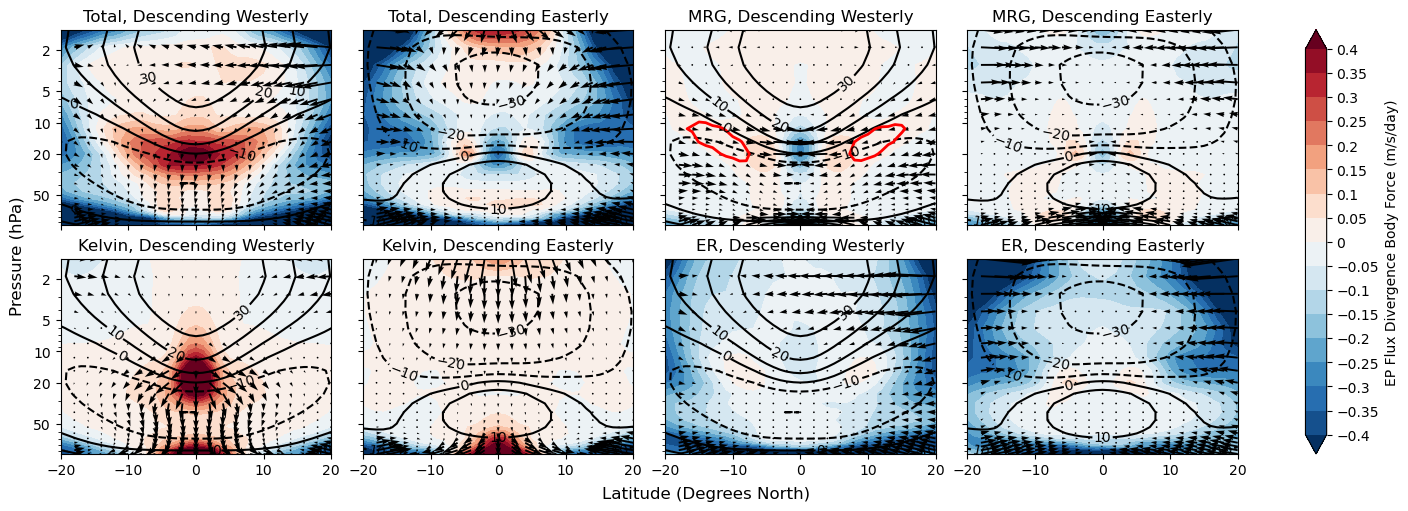

In [78]:
#### PLOT PARAMETERS ##########################################################
lev_bnds = [1,100]
shears = ['Descending Westerly','Descending Easterly']
nshear = len(shears)
yticks = [2,5,10,20,50,100];
ytick_labels = ['2', '5', '10', '20', '50', '100'];
# wavetypes to plot and their "short names" to be used in titles
choose_wt = ['no_filt','KELVIN_box_new','MRG_box','ER_box']
wt_snames = ['Total','Kelvin','MRG','ER']
vplot = 'utendepfd'
plot_sel = [-20.5,20.5] # latitude bounds for plotting
# levels for contour plot
#levels1 = [-0.2,-0.175,-0.15,-0.125,-0.1,-0.075,-0.05,-0.025,0,
#           0.025,0.05,0.075,0.1,0.125,0.15,0.175,0.2]
levels1 = [-0.4,-0.35,-0.3,-0.25,-0.2,-0.15,-0.1,-0.05,0,
           0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4]
ulevs = [-30,-20,-10,0,10,20,30]
# resample to every nth value in latitude for plotting EP flux
rs_lat = 2 
# plot these wavetypes in a n-column grid
num_cols = 2
###############################################################################
# Calculate grid size
# each column includes two sub-columns (descending westerly/easterly)
# each row within the column is a new wavetype
# first, calculate the number of rows needed
num_wts = len(choose_wt)
if num_wts%num_cols == 0:
    num_wtrows = num_wts//num_cols
else:
    num_wtrows = num_wts//num_cols + 1

num_wtcols = num_cols*2 # for descending w'ly/e'ly subcols
#### Create composites ####
composites = list(qd.we_split(epfd_concat.sel(lev = slice(*lev_bnds)), 20, False))

# initialize figure
fig11, ax11 = plt.subplots(num_wtrows, 
                           num_wtcols, 
                           figsize = (3.5*num_wtcols,2.5*num_wtrows),
                           sharex = True, 
                           sharey = True, 
                           layout = 'constrained')

wti = -1
for j in range(0,num_wtcols,2):
    for i in range(num_wtrows):
        wti += 1
        #print(wti)
        if wti >= num_wts:
            break
        for s in range(nshear):
            # descending westerly in left subcol, descending e'ly in right subcol
            wt = choose_wt[wti]
            datp = composites[s].sel(wavetype = wt, 
                                     lat = slice(*plot_sel)
                                    ).transpose('lev','lat')
            lats = datp.lat
            levs = datp.lev
            # plot variable contours for phase s
            im = ax11[i,j+s].contourf(lats,
                                      levs,
                                      datp[vplot],
                                      levels = levels1, 
                                      cmap = 'RdBu_r',
                                      norm = clr.BoundaryNorm(boundaries = levels1, 
                                                              ncolors = 256, 
                                                              extend = 'both'),
                                      extend = 'both')
            # add zonal wind contours 
            cs1 = ax11[i,j+s].contour(lats,
                                      levs,
                                      datp['Uzm'],
                                      levels = ulevs, 
                                      colors = 'black')
            ax11[i,j+s].clabel(cs1,
                               inline = True,
                               inline_spacing = 0,
                               fontsize = 10)
            # add barotropic instability contours for MRG
            if 'MRG' in wt:
                cs2 = ax11[i,j].contour(lats,
                                        levs,
                                        datp['dZdy'],
                                        levels = [0], 
                                        linewidths = 2, 
                                        colors = 'red')
    
            epfy_loc = datp['epfy']
            epfz_loc = datp['epfz']
            
            ax11[i,j+s].set_yscale('log')
            #ax11[s].invert_yaxis()
            ax11[i,j+s].set_yticks(yticks)
            ax11[i,j+s].set_yticklabels(ytick_labels)
            if (i==j==s==0):
                ax11[i,j+s].invert_yaxis()
            # after scaling the y-axis, rescale and plot EP Fluxes
            # resample to ? degree latitude grid
            lats_r = lats.isel(lat=slice(rs_lat, None, rs_lat))
            epfy_loc_r = epfy_loc.isel(lat=slice(rs_lat, None, rs_lat))
            epfz_loc_r = epfz_loc.isel(lat=slice(rs_lat, None, rs_lat))
    
            coslat = np.cos(np.deg2rad(lats_r))
            # Edmon et al (1980) scaling
            epfy_hat = 2*np.pi*(1/g0)*rearth*coslat*epfy_loc_r
            # last factor of 100 is to convert to 
            epfz_hat = 2*np.pi*(1/g0)*(rearth**2)*coslat*epfz_loc_r/100
            # get bounding box for axis
            bbox = ax11[i,j+s].get_window_extent()
            # dpi used to convert from display units to inches
            dpi = fig11.dpi
            Y = bbox.height/dpi
            X = bbox.width/dpi
    
            dphi = np.max(lats_r) - np.min(lats_r)
            p0_loc = np.max(levs)
            p1_loc = np.min(levs)
    
            a_lin = X/(dphi*(np.pi/180))
            b_log = -Y/(np.log(p0_loc/p1_loc)*levs)
    
            epfy_tilde = epfy_hat*a_lin
            epfz_tilde = epfz_hat*b_log
            
            
            ax11[i,j+s].quiver(lats_r,
                               levs,
                               epfy_tilde.transpose('lev','lat'),
                               epfz_tilde.transpose('lev','lat'),
                               color = 'k',
                               width = 0.003*X)
    
            ax11[i,j+s].set_title(f'{wt_snames[wti]}, {shears[s]}')
                
cbar = fig11.colorbar(im, ax = ax11.ravel())
cbar_ticks = levels1
cbar_ticks_str = []
for c in cbar_ticks:
    cnew = str(c).replace('-','\N{MINUS SIGN}')
    cbar_ticks_str.append(cnew)
cbar.set_ticks(cbar_ticks,labels = cbar_ticks_str)
cbar.set_label('EP Flux Divergence Body Force (m/s/day)')
fig11.supylabel('Pressure (hPa)')
fig11.supxlabel('Latitude (Degrees North)')
#fig11.suptitle(f'Wave Type: {wavetypes[w]}')

save_fpth = fig_dir + f'fltcomp_latlev_{vplot}_wt_'
for cw in choose_wt:
    save_fpth += cw + '_'
save_fpth += case_snames[0] + '.png'
fig11.savefig(save_fpth)    

## ii) Vertical profile composites

In [71]:
epfd_k_old = xr.open_dataset(
    '/glade/derecho/scratch/aaroj/aqua_qbo_data_proc/1xCO2/wave_data/1xCO2_mm_TEM_yrs_0003_0022_wt_KELVINb.nc')[[
    'U','utendepfd']].rename({'U':'Uzm'})
epfd_k_old['utendepfd'] = epfd_k_old.utendepfd.expand_dims(dim = {'wavetype':['KELVIN_box_old']})
old_coords = dict(epfd_k_old.coords)
epfd_k_new = xr.open_dataset(
    '/glade/derecho/scratch/aaroj/aqua_qbo_data_proc/1xCO2/wave_data/TEM_lat_30.5S.30N_yr_3.22_KELVIN_box_1xCO2.nc')[[
    'Uzm','utendepfd']].sel(lat = slice(-30,None), lev = slice(None,105))
old_coords['wavetype'] = ['KELVIN_box']
epfd_k_new = epfd_k_new.assign_coords(old_coords)
epfd_k_tot = xr.concat([epfd_k_old,epfd_k_new],'wavetype',data_vars = 'minimal')

<xarray.DataArray 'lat' (lat: 7)> Size: 56B
array([-3., -2., -1.,  0.,  1.,  2.,  3.])
Coordinates:
  * lat      (lat) float64 56B -3.0 -2.0 -1.0 0.0 1.0 2.0 3.0
Attributes:
    long_name:  latitude
    units:      degrees_north
[27, 28, 56, 57, 83, 84]
[13, 14, 41, 42, 69, 70, 96, 97]


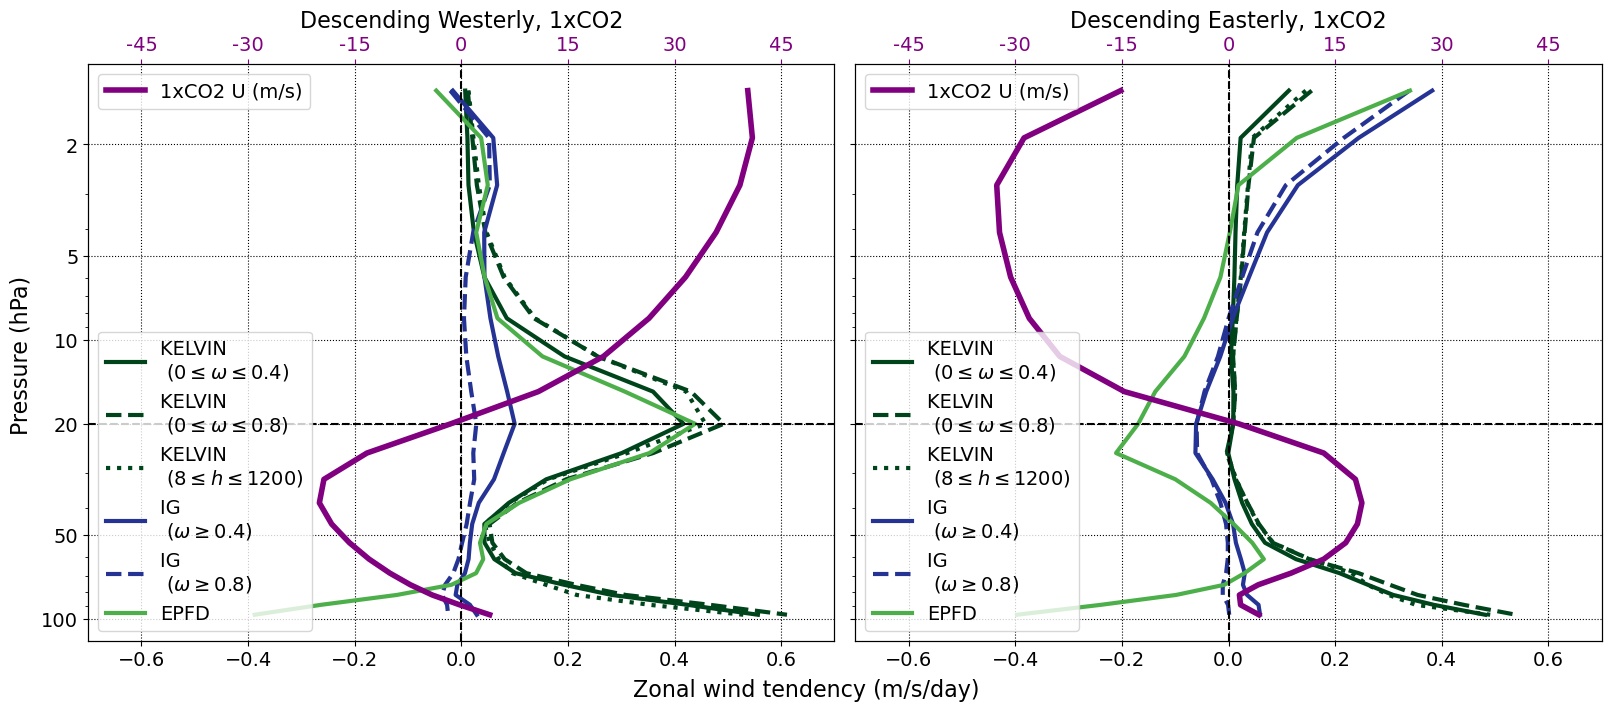

In [76]:
# Plot of wave-by-wave breakdown of EPFD for transition at 20 hPa
# add a new wave type that combines WIG_box and EIG_box
# because we have tested that it is valid to combine wave types
# after filtering (since Fourier transform is a linear operator?)
epfd_concat_loc = epfd_concat[['utendepfd','Uzm']]
epfd_sum = epfd_concat_loc['utendepfd'].sel(wavetype = 'WIG_box') + \
           epfd_concat_loc['utendepfd'].sel(wavetype = 'EIG_box')
epfd_sum = xr.Dataset({'utendepfd':epfd_sum.expand_dims(dim = {'wavetype':['IG_box_new']}),
                       'Uzm':epfd_concat['Uzm']})
epfd_concat_loc = xr.concat([epfd_concat_loc,epfd_sum],'wavetype',data_vars = 'minimal')

#### USER-DEFINED PARAMETERS ##################################################
# list of colors corresponding to each wave type (should be colorblind-friendly)
# choose_wt = ['KELVIN_box','MRG_box','ER_box','IG_box','no_filt']
# cepfd = ['#a1dab4','#2c7fb8','#41b6c4','#253494','black']
# linestys = ['dashed','dashdot','dotted',(0, (3, 1, 1, 1, 1, 1)),'solid']
# choose wavetypes to plot
choose_wt = ['KELVIN_box','KELVIN_box_new','KELVIN_jjf_new','IG_box','IG_box_new','no_filt']
wtnames = ['KELVIN \n ' + r'$(0 \leq \omega \leq 0.4)$',
           'KELVIN \n ' + r'$(0 \leq \omega \leq 0.8)$',
           'KELVIN \n ' + r'$(8 \leq h \leq 1200)$',
           'IG \n ' + r'$(\omega \geq 0.4)$',
           'IG \n ' + r'$(\omega \geq 0.8)$',
           'EPFD']
# choose colors for the vertical profiles
cepfd = ['#00441b','#00441b','#00441b','#253494','#253494','#4daf4a']
# choose linestyles for the vertical profiles
linestys = ['solid','dashed','dotted','solid','dashed','solid']

# Define cases and case names
num_cases = 1
cstr = ['Ctrl']
short_names_d = ['1xCO2']
short_names = ['1xCO2']

# Define data
epfd_cases = [epfd_concat_loc[['utendepfd','Uzm']]]
###############################################################################

#### OTHER PLOT PARAMETERS ####################################################
leg_loc = ['upper left','lower left']
lev_bnds = [1,100]
nwave = len(choose_wt)
shears = ['Descending Westerly','Descending Easterly']
nshear = len(shears)
yticks = [2,5,10,20,50,100];
ytick_labels = ['2', '5', '10', '20', '50', '100'];
###############################################################################


# do a tropical average 
md_zm_epfds = [epfd_case.sel(lev = slice(*lev_bnds),
                             lat = slice(-4,4)) for epfd_case in epfd_cases]
print(md_zm_epfds[0].lat)
md_zm_epfd_trs = [md_zm_epfd.weighted(np.cos(np.deg2rad(md_zm_epfd.lat))).mean(
    'lat', keep_attrs = True) for md_zm_epfd in md_zm_epfds] 

# assume all cases have the same pressure levels
plevs = md_zm_epfd_trs[0].lev

# strings for labeling shear zones and anomalies
all_cases = [[],[]]

# split dataset according to easterly and westerly QBO shear zones
for i in range(num_cases):
    dta_e2w, dta_w2e = qd.we_split(md_zm_epfd_trs[i], l = 20, do_smoothing=False);
    all_cases[0].append(dta_e2w)
    all_cases[1].append(dta_w2e)

fig_vv, ax_vv = plt.subplots(num_cases,2, sharex = False, sharey = True, 
                             layout = 'compressed', figsize = (16,7*num_cases))
counter = -1

for j in range(len(shears)): # Iterate over shear zones
    sh_data = all_cases[j]
    for i in range(num_cases): # Iterate over all cases
        counter += 1
        sd = short_names_d[i]
        if i != 0: # calculate tendency anomalies w.r.t. control
            control_dat = sh_data[0]
            co2_dat = sh_data[i]
            epfd = co2_dat['utendepfd'] - control_dat['utendepfd']
        else:
            epfd = sh_data[i]['utendepfd']
            
        #epfd_ig_ssg = epfd_ig + epfd_ssg
        u = sh_data[i]['Uzm']
        # plot zonal wind tendencies
        for wt in choose_wt:
            wti = choose_wt.index(wt)
            wt_name = wtnames[wti]
            epfd_wt = epfd.sel(wavetype = wt)
            ax_vv[j].plot(epfd_wt.values, 
                            plevs.values, 
                            label = wt_name, 
                            color = cepfd[choose_wt.index(wt)],
                            linewidth = 3,
                            linestyle = linestys[choose_wt.index(wt)])
        # create twin axis for zonal wind profile
        ax_vv2 = ax_vv[j].twiny()
        ax_vv2.plot(u.values, plevs.values, color = 'purple', linewidth = 4,
                   label = short_names[i] + " U (m/s)")
        # more plot formatting
        ax_vv2.legend(loc = 'upper left', fontsize = 14)
        ax_vv2.set_xlim([-52.5,52.5])
        ax_vv2.set_xticks([-45,-30,-15,0,15,30,45])
        ax_vv2.set_xticklabels(['-45','-30','-15','0','15','30','45'])
        ax_vv2.tick_params(axis='both', which = 'both', labelsize=14, colors = 'purple')
        ax_vv[j].axhline(y = 20, color = 'black', linestyle = 'dashed')
        ax_vv[j].axvline(x = 0, color = 'black', linestyle = 'dashed')

        if (i == 0 and j == 0):
            ax_vv[j].set_yscale('log')
            ax_vv[j].invert_yaxis()
            ax_vv[j].set_yticks([2,5,10,20,50,100])
            ax_vv[j].set_yticklabels(['2', '5', '10', '20', '50', '100'])
            
        ax_vv[j].grid(visible = True, color = 'k', linestyle = 'dotted')
        ax_vv[j].tick_params(axis='both', which = 'both', labelsize=14)
        if i == 0:
            legend2 = ax_vv[j].legend(loc = 'lower left', fontsize = 14)
            legend2.remove()
            ax_vv2.add_artist(legend2)
        ax_vv[j].set_xlim([-0.7,0.7])

        if i == 1:
            ax_vv[j].set_title(shears[j] + " EPFD Budget Composites (4S-4N Average) \n " +\
                                 short_names_d[i], fontsize = 16)
        else:
            ax_vv[j].set_title(shears[j] + ', ' + short_names_d[i], fontsize = 16)
    

fig_vv.supxlabel(r"Zonal wind tendency (m/s/day)", fontsize = 16)
fig_vv.supylabel("Pressure (hPa)", fontsize = 16)

save_fpth = fig_dir + 'eqcomp_wt_'
for cw in choose_wt:
    save_fpth += f'{cw}_'
for s in short_names:
    save_fpth += s + "."
save_fpth += "png"
fig_vv.savefig(save_fpth)


# 2) WK analysis of dynamical variables

## a) Create 12-hrly u,v,t, and omega perturbaton data

In [16]:
# subset data in latitude, level, and time
lat_filt = [-15.5,15]
plevs = [10,20,50,100,200]
num_levs = len(plevs)
start_yr = 3
end_yr = 22
yrs = list(np.arange(start_yr, end_yr + 1, 1))
yrs = [str(y).zfill(4) for y in yrs]
print(yrs)

# 6 hourly data filepath information
for i in range(num_cases):
    print(f'Processing case {case_snames[i]}')
    data_6hr_glob = glob(data_6hr_fpaths[i])
    data_6hr_glob.sort()
    # filter files by time
    data_6hr_glob = [d for d in data_6hr_glob if d.split('-')[0][-4:] in yrs]
    
    # open data
    all_data = xr.open_mfdataset(data_6hr_glob,
                                 parallel = True,
                                 concat_dim = 'time',
                                 combine = 'nested',
                                 data_vars = 'minimal',
                                 coords = 'minimal',
                                 compat = 'override')

    # select desired levels
    all_data_levsel = all_data.sel(lev = plevs, method = 'nearest')
    # select tropical latitudes
    all_data_trop = all_data_levsel.sel(lat = slice(*lat_filt))

    for v in vars: # iterate over variables for wk calculations
        print(f'Processing variable {v}')
        dat = all_data_trop[v]
        datp = dat - dat.mean('lon', keep_attrs = True)
        #print(f'Rechunking {v}')
        # if vars.index(v) == 0:
        #     datp = datp.chunk({'time':-1,
        #                        'lev':'auto',
        #                        'lat':'auto',
        #                        'lon':-1})
        #     auto_chunks = datp.chunksizes
        # else:
        #     datp = datp.chunk(auto_chunks)

        # print(datp)

        # resample
        # since we want to maintain instantaneous data, just select every
        # second value
        datp_12hr = datp.isel(time = slice(None,None,2)).compute()

        # do wk analysis
        for n in range(num_levs):
            l = plevs[n]
            # extract singular level from perturbation data
            data_var = datp_12hr.sel(lev = l, method = 'nearest')
            act_lev = data_var.lev.values.item()
            
            wk_dir = wk_paths[i]
            wk_data_fpath = wk_paths[i] + case_snames[i] + f'_wk_{v}_{act_lev:.1f}hPa.nc'
            
            data_wk = wd.wf_analysis(data_var,
                                     96,
                                     65,
                                     2,
                                     None)
            # save wavenumber-frequency analysis
            if os.path.exists(wk_data_fpath):
                os.remove(wk_data_fpath)
            data_wk.to_netcdf(wk_data_fpath)
        del datp_12hr
        
        

Processing case 1xCO2
Processing variable U


/glade/work/aaroj/conda-envs/qbo/lib/python3.9/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 11.61 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


data shape at beginning  (14600, 30, 360)
data shape after dosymmetries (14600, 30, 360)
[wk_calc] x_win shape is (233, 30, 360, 192)
No missing, so use simplest segment detrend.
data input to fft (233, 30, 360, 192)
shape of fft data is  (233, 30, 360, 192)
shape of z_arr  (233, 30, 360, 192)
z_final shape is  (2, 360, 192)
z_final coords are  Coordinates:
  * wavenumber  (wavenumber) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * frequency   (frequency) float64 2kB -1.0 -0.9896 -0.9792 ... 0.9792 0.9896
  * component   (component) <U13 104B 'symmetric' 'antisymmetric'
data shape at beginning  (14600, 30, 360)
data shape after dosymmetries (14600, 30, 360)
[wk_calc] x_win shape is (233, 30, 360, 192)
No missing, so use simplest segment detrend.
data input to fft (233, 30, 360, 192)
shape of fft data is  (233, 30, 360, 192)
shape of z_arr  (233, 30, 360, 192)
z_final shape is  (2, 360, 192)
z_final coords are  Coordinates:
  * wavenumber  (wavenumber) float64 3kB -180.0 -179.0 -1

/glade/work/aaroj/conda-envs/qbo/lib/python3.9/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 11.61 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


data shape at beginning  (14600, 30, 360)
data shape after dosymmetries (14600, 30, 360)
[wk_calc] x_win shape is (233, 30, 360, 192)
No missing, so use simplest segment detrend.
data input to fft (233, 30, 360, 192)
shape of fft data is  (233, 30, 360, 192)
shape of z_arr  (233, 30, 360, 192)
z_final shape is  (2, 360, 192)
z_final coords are  Coordinates:
  * wavenumber  (wavenumber) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * frequency   (frequency) float64 2kB -1.0 -0.9896 -0.9792 ... 0.9792 0.9896
  * component   (component) <U13 104B 'symmetric' 'antisymmetric'
data shape at beginning  (14600, 30, 360)
data shape after dosymmetries (14600, 30, 360)
[wk_calc] x_win shape is (233, 30, 360, 192)
No missing, so use simplest segment detrend.
data input to fft (233, 30, 360, 192)
shape of fft data is  (233, 30, 360, 192)
shape of z_arr  (233, 30, 360, 192)
z_final shape is  (2, 360, 192)
z_final coords are  Coordinates:
  * wavenumber  (wavenumber) float64 3kB -180.0 -179.0 -1

...

data shape at beginning  (14600, 30, 360)
data shape after dosymmetries (14600, 30, 360)
[wk_calc] x_win shape is (233, 30, 360, 192)
No missing, so use simplest segment detrend.
data input to fft (233, 30, 360, 192)
shape of fft data is  (233, 30, 360, 192)
shape of z_arr  (233, 30, 360, 192)
z_final shape is  (2, 360, 192)
z_final coords are  Coordinates:
  * wavenumber  (wavenumber) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * frequency   (frequency) float64 2kB -1.0 -0.9896 -0.9792 ... 0.9792 0.9896
  * component   (component) <U13 104B 'symmetric' 'antisymmetric'
data shape at beginning  (14600, 30, 360)
data shape after dosymmetries (14600, 30, 360)
[wk_calc] x_win shape is (233, 30, 360, 192)
No missing, so use simplest segment detrend.
data input to fft (233, 30, 360, 192)
shape of fft data is  (233, 30, 360, 192)
shape of z_arr  (233, 30, 360, 192)
z_final shape is  (2, 360, 192)
z_final coords are  Coordinates:
  * wavenumber  (wavenumber) float64 3kB -180.0 -179.0 -1

/glade/work/aaroj/conda-envs/qbo/lib/python3.9/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 11.70 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


data shape at beginning  (14600, 30, 360)
data shape after dosymmetries (14600, 30, 360)
[wk_calc] x_win shape is (233, 30, 360, 192)
No missing, so use simplest segment detrend.
data input to fft (233, 30, 360, 192)
shape of fft data is  (233, 30, 360, 192)
shape of z_arr  (233, 30, 360, 192)
z_final shape is  (2, 360, 192)
z_final coords are  Coordinates:
  * wavenumber  (wavenumber) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * frequency   (frequency) float64 2kB -1.0 -0.9896 -0.9792 ... 0.9792 0.9896
  * component   (component) <U13 104B 'symmetric' 'antisymmetric'
data shape at beginning  (14600, 30, 360)
data shape after dosymmetries (14600, 30, 360)
[wk_calc] x_win shape is (233, 30, 360, 192)
No missing, so use simplest segment detrend.
data input to fft (233, 30, 360, 192)
shape of fft data is  (233, 30, 360, 192)
shape of z_arr  (233, 30, 360, 192)
z_final shape is  (2, 360, 192)
z_final coords are  Coordinates:
  * wavenumber  (wavenumber) float64 3kB -180.0 -179.0 -1

/glade/work/aaroj/conda-envs/qbo/lib/python3.9/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 11.80 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


data shape at beginning  (14600, 30, 360)
data shape after dosymmetries (14600, 30, 360)
[wk_calc] x_win shape is (233, 30, 360, 192)
No missing, so use simplest segment detrend.
data input to fft (233, 30, 360, 192)
shape of fft data is  (233, 30, 360, 192)
shape of z_arr  (233, 30, 360, 192)
z_final shape is  (2, 360, 192)
z_final coords are  Coordinates:
  * wavenumber  (wavenumber) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * frequency   (frequency) float64 2kB -1.0 -0.9896 -0.9792 ... 0.9792 0.9896
  * component   (component) <U13 104B 'symmetric' 'antisymmetric'
data shape at beginning  (14600, 30, 360)
data shape after dosymmetries (14600, 30, 360)
[wk_calc] x_win shape is (233, 30, 360, 192)
No missing, so use simplest segment detrend.
data input to fft (233, 30, 360, 192)
shape of fft data is  (233, 30, 360, 192)
shape of z_arr  (233, 30, 360, 192)
z_final shape is  (2, 360, 192)
z_final coords are  Coordinates:
  * wavenumber  (wavenumber) float64 3kB -180.0 -179.0 -1

In [13]:
client.restart()

## b) Filter plotting functions

In [104]:
def swap_filt(filt_dict_in):
    '''
    Swaps components ('sym' and 'asym') in filter dictionary. Useful
    for meridional wind (V), for which MRG wave power appears in symmetric 
    component instead of antisymmetric component.
    '''
    # make local copy of dictionary 
    filter_dict = copy.deepcopy(filt_dict_in)
    filter_keys = list(filter_dict.keys())
    # swap component keys if necessary
    # iterate over wavetypes
    for ky in filter_keys:
        comp_keys = list(filter_dict[ky].keys())
        if len(comp_keys) == 2:
            # get old keys
            old_sym = filter_dict[ky].pop('sym')
            old_asym = filter_dict[ky].pop('asym')
            # swap
            filter_dict[ky]['sym'] = old_asym
            filter_dict[ky]['asym'] = old_sym
        elif len(comp_keys) == 1:
            if comp_keys[0] == 'sym':
                filter_dict[ky]['asym'] = filter_dict[ky].pop('sym')
            else:
                filter_dict[ky]['sym'] = filter_dict[ky].pop('asym')
    return filter_dict

def plot_filters(ax_sym,
                 ax_asym,
                 wn, 
                 filt_dict,
                 filt_labels,
                 facecolors,
                 hatches,
                 edgecolors,
                 edgestyles,
                 linewidths,
                 sfilt = False,
                 u_shift = None, 
                 rescale = True):
    '''
    Plot wavenumber-frequency filters on a matplotlib axis

    ax: matplotlib.pyplot.axis- axis on which to plot filter
    wavetype: string- name of wave whose filter is to be plotted. If
    a dispersion rel'n-based filter is desired, the name should be 
    formatted as 'NAME_identifier', where 'NAME' is in the allowed
    wavetypes list in calc_dispersion and 'identifier' is a more specific
    name for the filter.
    wn: array_like- array of wavenumbers (x-axis)
    kbnd: list- wavenumber bounds for filter
    fbnd: list- frequency bounds for filter
    hbnd: list- equivalent depth bounds for filter. If creating a box filter,
    set elements to None
    edgecolor: string- color for filter boundaries
    edgestyle: string- linestyle for filter boundaries
    u_shift: numeric type- background wind speed for doppler-shifting
    dispersion relationships and filters
    rescale: bool- whether to rescale output frequencies to counts/day
    '''
    wn_rescale = wn/rearth
    
    if sfilt:
        filt_dict_loc = swap_filt(filt_dict)
    else:
        filt_dict_loc = copy.deepcopy(filt_dict)
        
    # iterate over wavetypes and components to plot all filters
    wavetypes = list(filt_dict_loc.keys())
    sym_handles = []
    asym_handles = []
    for wt in wavetypes:
        wti = wavetypes.index(wt)
        # could we just filter this to remove a component if
        # its corresponding axis is set to None?
        components = list(filt_dict_loc[wt].keys())
        for c in components:
            # get filter parameters
            kbnd = filt_dict_loc[wt][c]['kbnd']
            fbnd = filt_dict_loc[wt][c]['fbnd']
            hbnd = filt_dict_loc[wt][c]['hbnd']
            
            if ((c == 'sym')&(ax_sym != None)):
                ax_ylim = ax_sym.get_ylim()
                ax_xlim = ax_sym.get_ylim()
            elif ((c == 'asym')&(ax_asym != None)):
                ax_ylim = ax_asym.get_ylim()
                ax_xlim = ax_asym.get_xlim()
            else:
                ax_ylim = [-np.inf,np.inf]
                ax_xlim = [-np.inf,np.inf]

            if kbnd[0] == None:
                kbnd[0] = ax_xlim[0]
            if kbnd[1] == None:
                kbnd[1] = ax_xlim[1]
                
            if len(fbnd) > 2:
                dbox_flag = True
                # in this case, do different frequency
                # bounds on either side of k = 0
                # but, need to make sure wavenumber 
                # bounds cross zero for this to work
                assert kbnd[0]*kbnd[1] < 0 
                for i in range(0,len(fbnd),2):
                    if fbnd[i] == None:
                        fbnd[i] = ax_ylim[0]
                    if fbnd[i+1] == None:
                        fbnd[i+1] = ax_ylim[1]
            else:
                dbox_flag = False
                if fbnd[0] == None:
                    fbnd[0] = ax_ylim[0]
                if fbnd[1] == None:
                    fbnd[1] = ax_ylim[1]
                
            if not (None in hbnd):
                # don't want separate freq. boxes in this case
                assert (dbox_flag == False)
                wt_prefix = wt.split('_')[0]
                disp_relns = kfd.calc_dispersion(wt_prefix,
                                                 wn_rescale,
                                                 np.array(hbnd),
                                                 u_shift,
                                                 rescale)
        
                # filter the results according to kbnd
            
                disp_minf = disp_relns[hbnd[0]][(wn >= kbnd[0])&(wn <= kbnd[1])]
                disp_maxf = disp_relns[hbnd[1]][(wn >= kbnd[0])&(wn <= kbnd[1])]
                wn_filt = wn[(wn >= kbnd[0])&(wn <= kbnd[1])]
            
                # filter the results according to fbnd
                disp_minf[disp_minf <= fbnd[0]] = fbnd[0]
                disp_maxf[disp_maxf >= fbnd[1]] = fbnd[1]
            else:
                wn_filt = wn[(wn >= kbnd[0])&(wn <= kbnd[1])]
                if dbox_flag:
                    wn_filt_l0 = wn_filt[wn_filt<=0]
                    wn_filt_g0 = wn_filt[wn_filt>=0]
                    wn_filt_new = np.concatenate([wn_filt_l0,wn_filt_g0])
                    disp_minf1 = np.ones_like(wn_filt_l0)*fbnd[-4]
                    disp_minf2 = np.ones_like(wn_filt_g0)*fbnd[-2]
                    disp_minf = np.concatenate([disp_minf1,disp_minf2])
                    disp_maxf1 = np.ones_like(wn_filt_l0)*fbnd[-3]
                    disp_maxf2 = np.ones_like(wn_filt_g0)*fbnd[-1]
                    disp_maxf = np.concatenate([disp_maxf1,disp_maxf2])
                    
                else:
                    disp_minf = np.ones_like(wn_filt)*fbnd[0]
                    disp_maxf = np.ones_like(wn_filt)*fbnd[1]

            handle = mpatches.Patch(facecolor = facecolors[wti],
                                    edgecolor = edgecolors[wti],
                                    # increase hatch density
                                    hatch = 3*hatches[wti],
                                    linestyle = edgestyles[wti],
                                    label = filt_labels[wti])
            
            if ((c == 'sym')&(ax_sym != None)):
                if dbox_flag:
                    wn_filt = wn_filt_new
                    print(wn_filt_new)
                    print(np.shape(wn_filt_new))
                    print(disp_minf)
                    print(disp_maxf)
                fill_poly = ax_sym.fill_between(wn_filt, 
                                                disp_minf, 
                                                disp_maxf, 
                                                facecolor = facecolors[wti],
                                                edgecolor = edgecolors[wti],
                                                hatch = hatches[wti],
                                                linestyle = edgestyles[wti],
                                                linewidth = linewidths[wti])
                
                sym_handles.append(handle)
                # (x0, y0), (x1, y1) = fill_poly.get_paths()[0].get_extents().get_points()

                # ax_sym.text((x0 + x1) / 2, (y0 + y1) / 2, wt, ha='center', 
                #             va='center', fontsize=16, color=edgecolors[wti])
            elif ((c == 'asym')&(ax_asym != None)):
                if dbox_flag:
                    wn_filt = wn_filt_new
                fill_poly = ax_asym.fill_between(wn_filt, 
                                                 disp_minf, 
                                                 disp_maxf, 
                                                 facecolor = facecolors[wti],
                                                 edgecolor = edgecolors[wti],
                                                 hatch = hatches[wti],
                                                 linestyle = edgestyles[wti],
                                                 linewidth = linewidths[wti])
                asym_handles.append(handle)

            


    return sym_handles, asym_handles
    
def plot_disps(ax_sym,
               ax_asym,
               filt_dict, 
               wn, 
               hdepths, 
               sfilt = False,
               u_shift = None, 
               rescale = True):
    '''
    Plot dispersion curves on a wavenumber-frequency matplotlib
    axis

    ax: matplotlib.pyplot.axis- axis on which to plot filter
    wavetype: string- name of wave whose dispersion curve is to be plotted
    wn: array_like- array of wavenumbers (x-axis)
    hdepths: list- dispersion rel'n equivalent depths
    u_shift: numeric type- background wind speed for doppler-shifting
    dispersion relationships
    rescale: bool- whether to rescale frequencies to counts/day
    for plotting
    '''
    wn_rescale = wn/rearth

    if sfilt:
        filt_dict_loc = swap_filt(filt_dict)
    else:
        filt_dict_loc = copy.deepcopy(filt_dict)

    #pdb.set_trace()
    wavetypes = list(filt_dict_loc.keys())
    wavetypes = \
    [w.split('_')[0] for w in wavetypes if w.split('_')[0] != 'BOX']
    wavetypes = list(set(wavetypes)) # remove duplicate wavetypes
    #print(wavetypes)

    for wt in wavetypes:
        component = list(filt_dict_loc[wt].keys())[0]
        disp_relns = kfd.calc_dispersion(wt,
                                         wn_rescale,
                                         np.array(hdepths),
                                         u_shift,
                                         rescale,
                                         fill_val = np.nan)
        for hd in hdepths:
            if ((component == 'sym')&(ax_sym != None)):
                ax_sym.plot(wn,
                            disp_relns[hd],
                            color = 'black')
            elif ((component == 'asym')&(ax_asym != None)):
                ax_asym.plot(wn,
                             disp_relns[hd],
                             color = 'black')

    return None

## c) Create WK Plots

[-20. -19. -18. -17. -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.
  -6.  -5.  -4.  -3.  -2.  -1.   0.   0.   1.   2.   3.   4.   5.   6.
   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  17.  18.  19.  20.]
(42,)
[0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8
 0.8 0.8 0.8 0.8 0.8 0.8]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[-20. -19. -18. -17. -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.
  -6.  -5.  -4.  -3.  -2.  -1.   0.   0.   1.   2.   3.   4.   5.   6.
   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  17.  18.  19.  20.]
(42,)
[0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8
 0.8 0.8 0.8 0.8 0.8 0.8]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1

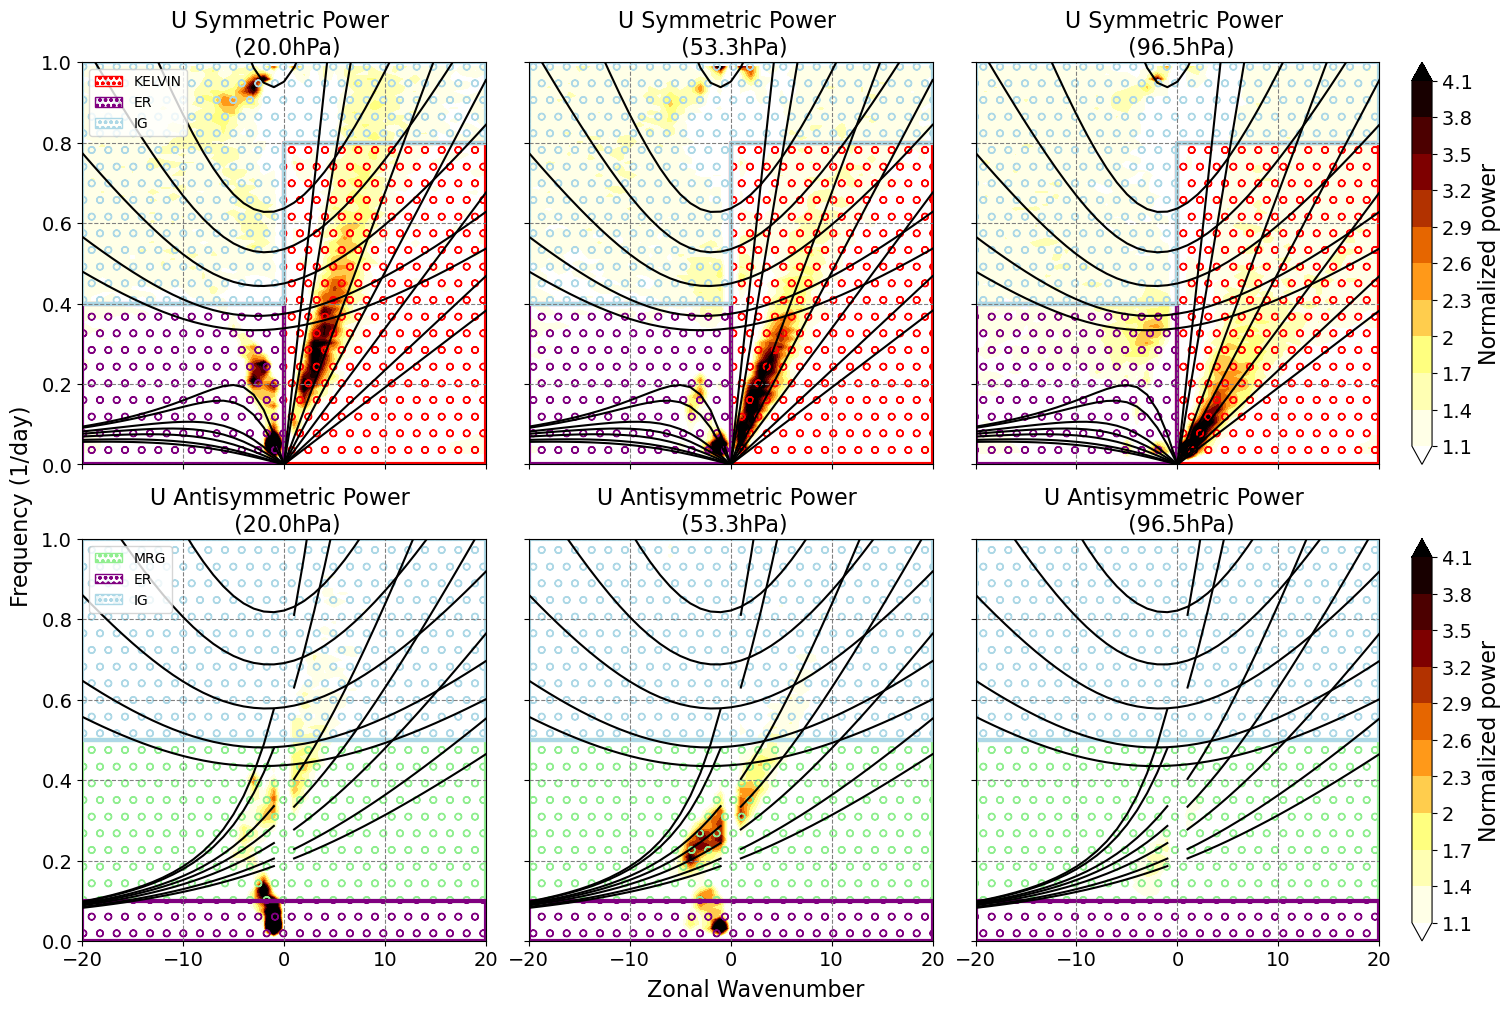

In [107]:
##### Wheeler-Kiladis filtering information ###################################
# wavenumber, frequency, and equivalent depth ranges for wave filters

filter_ranges = {'KELVIN_box':{'sym':{'kbnd':[0,20],
                                      'fbnd':[0,0.8],
                                      'hbnd':[None,None]}},
                 'MRG_box':{'asym':{'kbnd':[-20,20],
                                    'fbnd':[0.1,0.5],
                                    'hbnd':[None,None]}},
                 'ER_box':{'sym':{'kbnd':[-20,0],
                                  'fbnd':[0,0.4],
                                  'hbnd':[None,None]},
                           'asym':{'kbnd':[-20,20],
                                   'fbnd':[0,0.1],
                                   'hbnd':[None,None]}},
                 'IG_box':{'sym':{'kbnd':[-20,20],
                                  'fbnd':[0.4,None,0.8,None],
                                  'hbnd':[None,None]},
                           'asym':{'kbnd':[-20,20],
                                   'fbnd':[0.5,None],
                                   'hbnd':[None,None]}}}

# filter_ranges = {'KELVIN_box':{'sym':{'kbnd':[0,20],
#                                       'fbnd':[0,0.4],
#                                       'hbnd':[None,None]}},
#                  'KELVIN_box_new':{'sym':{'kbnd':[0,20],
#                                       'fbnd':[0,0.8],
#                                       'hbnd':[None,None]}},
#                  'KELVIN_jjf_new':{'sym':{'kbnd':[1,20],
#                                       'fbnd':[1/30,0.8],
#                                       'hbnd':[8,1200]}},
#                  }

wavetypes = list(filter_ranges.keys())
###############################################################################

#### PLOTTING PARAMETERS ######################################################
# which variables to plot
#vars = ['U','V','T','OMEGA']
vars = ['U']
# equivalent depths for dispersion curves
hdepths = [8,12,25,50,100,500,1200]
hdepths_arr = np.array(hdepths)
ubar = 0 # background wind for dispersion rel'n 
# frequency and wavenumber bounds for plot
fb = [0, 1]  
wb = [-20,20] 
#### Filter styling options ####
# filter edge color
wt_edgecolors = ['red','lightgreen','purple','lightblue']
# filter edge line style
wt_linestyles = ['solid','solid','solid','solid']
# filter face colors
wt_facecolors = ['none','none','none','none']
# filter hatch style
#wt_hatches = ['\\', '', 'o']
wt_hatches = ['o','o','o','o']
# filter short names
# wt_labels = ['KELVIN \n ' + r'$(0 \leq \omega \leq 0.4)$',
#              'KELVIN \n ' + r'$(0 \leq \omega \leq 0.8)$',
#              'KELVIN \n ' + r'$(8 \leq h \leq 1200)$']
wt_labels = ['KELVIN','MRG','ER','IG']
# edge line widths
wt_linewidths = [3,3,3,3]

# dictionary of waves for which to plot dispersion curves
disp_waves = {'KELVIN':{'sym':[]},
              'MRG':{'asym':[]},
              'ER':{'sym':[]},
              'IG0':{'asym':[]},
              'IG1':{'sym':[]},
              'IG2':{'asym':[]}}
# which pressure levels to plot
# (these need to match the levels in the filenames
# out to one decimal place)
#plevs_plot = [11.5,20.0,53.3,96.5,201.0] 
plevs_plot = [20.0,53.3,96.5]
num_pltlevs = len(plevs_plot)
# which components to plot (each will get a row)
comps_plt = ['symmetric','antisymmetric']
num_comps = len(comps_plt)

###############################################################################

for i in range(num_cases):    
    # do wk analysis and plot for each variable
    #pdb.set_trace()
    for var in vars:
        figb, axb = plt.subplots(num_comps,num_pltlevs, sharex = True, sharey = True, 
                                 figsize = (5*num_pltlevs, 5*num_comps), layout = 'compressed')
        if num_comps == 1:
            axb = axb[np.newaxis,:]
        for n in range(num_pltlevs):
            l = plevs_plot[n]
            # filepath to check for existing wf analysis data
            wk_data_fpath = wk_paths[i] + case_snames[i] + f'_wk_{var}_{l}hPa.nc'
            data_wk = xr.open_dataset(wk_data_fpath)
            #print(f'Found WK data for {var} at {act_lev:.1f}hPa.') 
            for c in range(num_comps):
                cmp = comps_plt[c]
                s = data_wk[cmp].load()
                """Basic plot of normalized power spectrum with shallow water curves."""
                z = s.transpose().sel(frequency=slice(*fb), wavenumber=slice(*wb))
                z.loc[{'frequency':0}] = np.nan
                kmesh0, vmesh0 = np.meshgrid(z['wavenumber'], z['frequency'])
                levs = [1.1,1.4,1.7,2,2.3,2.6,2.9,3.2,3.5,3.8,4.1]
                img = axb[c,n].contourf(kmesh0, vmesh0, z, levels=levs, cmap='afmhot_r',  extend='both')
                axb[c,n].grid(color = 'grey', linestyle = 'dashed')
                axb[c,n].set_xlim(wb)
                axb[c,n].set_ylim(fb)
                axb[c,n].set_title(f"{var} {cmp.capitalize()} Power \n ({l}hPa)", 
                                 fontsize = 16)
                axb[c,n].tick_params(axis='both', which = 'both', labelsize=14)
        
                if n == num_pltlevs - 1:
                    cbars = figb.colorbar(img, ax = axb[c,n])
                    cbars_ticks = levs
                    cbars_ticks_str = []
                    for cs in cbars_ticks:
                        cnews = str(cs).replace('-','\N{MINUS SIGN}')
                        cbars_ticks_str.append(cnews)
                    cbars.set_ticks(cbars_ticks,labels = cbars_ticks_str)
                    cbars.ax.tick_params(labelsize = 14)
                    cbars.ax.set_ylabel('Normalized power', rotation = 90, fontsize = 16)
        
                figb.supxlabel("Zonal Wavenumber", fontsize = 16)
                figb.supylabel("Frequency (1/day)", fontsize = 16)
        
            # plot dispersion curves and filter regions
            # flip components for V
            wn = z.wavenumber.values

            # need to plot the filters on the opposite 
            # component's axis for V
            if var == 'V':
                sfilt = True
            else:
                sfilt = False
                
            # figure out on which axes to plot the filters
            # and dispersion curves
            try:
                sym_idx = comps_plt.index('symmetric')
                ax_sym = axb[sym_idx,n]
            except ValueError:
                ax_sym = None

            try:
                asym_idx = comps_plt.index('antisymmetric')
                ax_asym = axb[asym_idx,n]
            except ValueError:
                ax_asym = None

            #pdb.set_trace()
            # plot dispersion curves
            plot_disps(ax_sym,
                       ax_asym,
                       disp_waves,
                       wn,
                       hdepths,
                       sfilt = sfilt)
            # plot filters
            sym_handles, asym_handles = plot_filters(ax_sym,
                                                     ax_asym,
                                                     wn,
                                                     filter_ranges,
                                                     wt_labels,
                                                     wt_facecolors,
                                                     wt_hatches,
                                                     wt_edgecolors,
                                                     wt_linestyles,
                                                     wt_linewidths,
                                                     sfilt = sfilt)

            if n == 0:
                if ax_sym != None:
                    ax_sym.legend(handles = sym_handles,loc='upper left')
                if ax_asym != None:
                    ax_asym.legend(handles = asym_handles, loc = 'upper left')
            
        save_fpth = fig_dir + f"{var}_WK_PS_"
        if ubar >= 0:
            save_fpth += f'plus{ubar}_'
        else:
            save_fpth += f'minus{ubar}_'

        save_fpth += 'wt_'
        for wt in wavetypes:
            save_fpth += f'{wt}_'

        save_fpth += 'lev_'
    
        for plev in plevs_plot:
            if plevs_plot.index(plev) == num_pltlevs - 1:
                save_fpth += f'{plev}'
            else:
                save_fpth += f'{plev}_'
        save_fpth += f"hPa_{case_snames[i]}.png"
        figb.savefig(save_fpth)

# Cluster control

In [17]:
client.restart()

In [17]:
cluster.scale(0)

In [25]:
cluster.close()
client.shutdown()